# Project #1 — Train and Compare Classic ML Algorithms
## Telco Customer Churn: will a customer leave the phone company?

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 customers, 21 columns, about 26.5% of them churned (left the company).

**Goal:** predict the column `Churn` (Yes / No) from the customer's profile, services and billing, train **4 models**, compare them **with numbers** against a baseline, and explain which one works best and why.

**How to run:** keep `WA_Fn-UseC_-Telco-Customer-Churn.csv` in the same folder as this notebook, then *Kernel → Restart & Run All*. The whole notebook runs in about 2–3 minutes.

### Map of this notebook

| Brief step | Section in this notebook | Course checklist (10 steps) |
|---|---|---|
| 1. Explore the data | **Step 1** — size, types, missing values, target, 3 plots | 01 Problem & metric · 02 EDA |
| 2. Prepare the data | **Step 2** — cleaning, duplicates, split · **Step 2b** — feature engineering (6 tools) · **Step 2c** — scaling | 03 Cleaning · 04 Split · 05 Features |
| 3. Baseline | **Step 3** — `DummyClassifier` + a simple logistic regression | 06 Baseline |
| 4. Train ≥ 2 models | **Step 4** — Logistic Regression, Random Forest, XGBoost, SVM, cross-validation, tuning | 07 Strong models · 08 CV · 09 Tuning in a Pipeline |
| 5. Evaluate on test | **Step 5** — the test set, used once: confusion matrix, precision, recall, F1 | 10 Test once |
| 6. Conclusion | **Step 6** — recommended model, gain over baseline, limitations | — |
| Bonus | 4 models · `RandomizedSearchCV` + `GridSearchCV` · feature importance · k-Means | — |

**The golden rule used everywhere below:** the test set is set aside at the start and touched **exactly once**, at the end (Step 5). Every decision before that — which features, which model, which hyperparameters, which threshold — is made with **cross-validation on the training set only**.

## Setup

We import everything once at the top, so the notebook reads top to bottom and a missing library fails immediately, not halfway through.

**What I do and why:** I load all the libraries once at the top and fix one random seed (42), so the notebook runs in order and gives the same results every time.

In [1]:
# --- Standard library ---
import warnings                                      # lets us catch or hide warning messages

# --- Data handling and plotting ---
import numpy as np                                   # fast numerical arrays and math functions
import pandas as pd                                  # DataFrames: tables with named columns
import matplotlib.pyplot as plt                      # the plotting library used for every chart

# --- scikit-learn: splitting, cross-validation and tuning ---
from sklearn.model_selection import (
    train_test_split,                                # one random split into train / test
    cross_val_score,                                 # one score per fold (used for the per-fold box plots)
    validation_curve,                                # train vs validation score while one hyperparameter changes
    StratifiedKFold,                                 # k folds that keep the churn share equal in every fold
    cross_validate,                                  # runs cross-validation and returns several metrics at once
    cross_val_predict,                               # out-of-fold predictions: each row predicted by a model that never saw it
    RandomizedSearchCV,                              # tries N random hyperparameter combinations with CV
    GridSearchCV,                                    # tries every combination of a small grid with CV
)

# --- scikit-learn: preprocessing and pipelines ---
from sklearn.compose import ColumnTransformer        # applies different preprocessing to numeric and text columns
from sklearn.pipeline import Pipeline                # chains steps so they are always fitted together (no leakage)
from sklearn.preprocessing import StandardScaler     # scaling: mean 0, standard deviation 1
from sklearn.preprocessing import OneHotEncoder      # encoding: one 0/1 column per category
from sklearn.preprocessing import FunctionTransformer  # turns our own feature function into a pipeline step
from sklearn.base import clone                       # makes a fresh, unfitted copy of a model

# --- scikit-learn + xgboost: models ---
from sklearn.dummy import DummyClassifier            # the "knows nothing" baseline
from sklearn.linear_model import LogisticRegression  # model 1: linear, probability-based (Session 7)
from sklearn.ensemble import RandomForestClassifier  # model 2: many decision trees voting (Session 8)
from xgboost import XGBClassifier                    # model 3: gradient-boosted trees (Session 9)
from sklearn.svm import SVC                          # model 4: Support Vector Machine (Session 9)
from sklearn.cluster import KMeans                   # bonus: k-Means clustering (Session 10)

# --- scikit-learn: metrics and inspection ---
from sklearn.metrics import make_scorer              # wraps a metric function so CV can use it
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # label-based metrics
from sklearn.metrics import roc_auc_score, average_precision_score                   # ranking metrics: ROC-AUC, PR-AUC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report            # error table + text report
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay                  # ROC and precision-recall curves
from sklearn.inspection import permutation_importance  # bonus: how much each column matters to a fitted model
from sklearn.exceptions import ConvergenceWarning    # the warning raised when a model stops before it converged
from scipy.stats import loguniform, randint, uniform # random distributions for RandomizedSearchCV

# --- Global settings ---
RANDOM_STATE = 42                                    # one seed everywhere -> identical results on every run
pd.set_option("display.max_columns", 50)             # show all columns when a DataFrame is printed
plt.rcParams["figure.figsize"] = (8, 4.5)            # default chart size
print("Libraries loaded.")                           # confirmation that the cell ran

Libraries loaded.


**What this cell does:** loads every library the project uses: `pandas`/`numpy` for the data, `matplotlib` for charts, scikit-learn for splitting, preprocessing, models, metrics and tuning, and `xgboost` for the XGBoost model. `RANDOM_STATE = 42` is passed to every random step (split, folds, models, searches), so anyone who re-runs the notebook gets exactly the same numbers.

### Project roadmap

The whole notebook in one picture. Everything in the orange zone is decided with cross-validation on the **training set only**; the red box is the only place where the test set is used.

**What I do and why:** I draw a map of my project so I can see the order of the steps and where the test set is used.

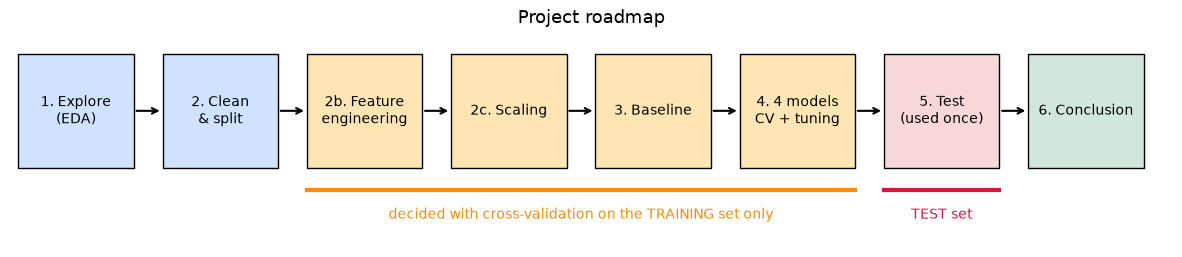

In [2]:
labels = ["1. Explore\n(EDA)", "2. Clean\n& split", "2b. Feature\nengineering", "2c. Scaling",   # one label per box
          "3. Baseline", "4. 4 models\nCV + tuning", "5. Test\n(used once)", "6. Conclusion"]
colors = ["#cfe2ff", "#cfe2ff", "#ffe5b4", "#ffe5b4",                     # blue = data work, orange = training-only decisions
          "#ffe5b4", "#ffe5b4", "#f8d7da", "#d1e7dd"]                     # red = test set, green = result
step = 1.75                                                               # horizontal distance between two boxes
fig, ax = plt.subplots(figsize=(15, 2.8))                                 # a wide, short canvas
for i, (label, color) in enumerate(zip(labels, colors)):                  # draw every box
    ax.add_patch(plt.Rectangle((i * step, 0), 1.4, 1, facecolor=color, edgecolor="black"))  # the box itself
    ax.text(i * step + 0.7, 0.5, label, ha="center", va="center", fontsize=10)  # its label, centred in the box
    if i < len(labels) - 1:                                               # every box except the last gets an arrow
        ax.annotate("", xy=((i + 1) * step, 0.5), xytext=(i * step + 1.4, 0.5),   # from this box to the next
                    arrowprops=dict(arrowstyle="->", lw=1.5))             # arrow style
ax.plot([2 * step, 5 * step + 1.4], [-0.2, -0.2], color="darkorange", lw=3)  # bracket under the training-only steps
ax.text(3.5 * step + 0.7, -0.45, "decided with cross-validation on the TRAINING set only",  # its caption
        ha="center", color="darkorange")
ax.plot([6 * step, 6 * step + 1.4], [-0.2, -0.2], color="crimson", lw=3)  # bracket under the test step
ax.text(6 * step + 0.7, -0.45, "TEST set", ha="center", color="crimson")  # its caption
ax.set_xlim(-0.1, len(labels) * step)                                     # make room for all boxes
ax.set_ylim(-0.7, 1.2)                                                    # make room for the brackets
ax.axis("off")                                                            # no axes: this is a diagram, not a chart
ax.set_title("Project roadmap", fontsize=13)                              # title
plt.show()                                                                # draw it

**What this cell does:** draws the project as a row of boxes: `plt.Rectangle` draws each box, `ax.text` writes the step name inside it, and `ax.annotate` with `arrowprops` draws the arrows. Two coloured lines under the boxes act as brackets: orange for everything decided on the training set with cross-validation (features, scaling, baseline, models, tuning), red for the single use of the test set. `ax.axis("off")` hides the axes because this is a diagram.

---
# Step 1 — Explore the data (EDA)

### 1.1 Load the dataset

We read the CSV with a **relative path** (just the file name), so the notebook works for anyone who clones the repository.

**What I do and why:** I load the CSV with just its file name, so the notebook works for anyone who downloads my repository.

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")  # the CSV sits in the same folder as this notebook
print("Rows x columns:", df.shape)                        # (number of customers, number of columns)
df.head()                                                 # show the first 5 customers

Rows x columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**What this cell does:** `pd.read_csv` loads the file into a DataFrame `df`; `df.shape` confirms **7,043 customers × 21 columns**; `df.head()` shows the first five rows. Each row is one customer: an ID, demographics (`gender`, `SeniorCitizen`, `Partner`, `Dependents`), how long they have been a customer (`tenure`, in months), which services they have (phone, internet, 6 internet add-ons), the contract and billing (`Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`) and the target `Churn`.

### 1.2 Column types

Before any model we need to know which columns are numbers and which are text, because models only understand numbers.

**What I do and why:** I check the type of every column, because models only work with numbers and I need to know what to convert.

In [4]:
df.info()   # column names, number of non-empty values and data type of every column

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**What this cell does:** `df.info()` lists every column with its non-null count and type. Only **3 columns are numeric** (`SeniorCitizen`, `tenure`, `MonthlyCharges`); the other 18 are text (`str`). Two surprises to fix in Step 2: **`TotalCharges` is text** although it is clearly an amount of money, and `SeniorCitizen` is already 0/1 while the other yes/no columns are the words "Yes"/"No".

### 1.3 Missing values

`isna()` only finds real empty cells (`NaN`). Missing values can also hide as empty strings or special words, so we check `TotalCharges` explicitly.

**What I do and why:** I look for missing values, including hidden ones: `TotalCharges` is text, so empty strings would not show up as NaN.

In [5]:
print("Missing values reported by isna():", df.isna().sum().sum())  # pandas reports no NaN anywhere...

blank_total = df["TotalCharges"].str.strip() == ""                   # ...but TotalCharges is text: look for empty strings
print("Blank TotalCharges values:", blank_total.sum())               # how many hidden missing values there are
df.loc[blank_total, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]  # show those rows

Missing values reported by isna(): 0
Blank TotalCharges values: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**What this cell does:** the first line sums `isna()` over the whole table and gets **0** — it looks clean. The second line strips spaces from `TotalCharges` and compares with `""`: **11 customers have a blank `TotalCharges`**. The table shows why: all 11 have **`tenure = 0`** — they have just signed up and have not been billed yet. This is the classic Telco trap: the blanks are why pandas read the whole column as text.

### 1.4 The target: how many customers churn?

**What I do and why:** I check how many customers churn, because if the classes are unbalanced, accuracy will not be a good metric.

In [6]:
churn_counts = df["Churn"].value_counts()                         # number of customers per class
churn_share = df["Churn"].value_counts(normalize=True)            # the same, as a share of all customers
pd.DataFrame({"customers": churn_counts, "share": churn_share.round(3)})  # one small table with both

,customers,share
Churn,,
No,5174,0.735
Yes,1869,0.265


**What this cell does:** `value_counts()` counts each class and `normalize=True` turns the counts into shares: **5,174 customers stayed (73.5%) and 1,869 churned (26.5%)**. The classes are **imbalanced**: a model that always answers "No" would already be right 73.5% of the time, so accuracy alone will be misleading (Step 3 proves it).

### 1.5 Three plots

Each plot is followed by one sentence about what it shows.

**What I do and why:** Plot 1: I show the balance between the two classes.

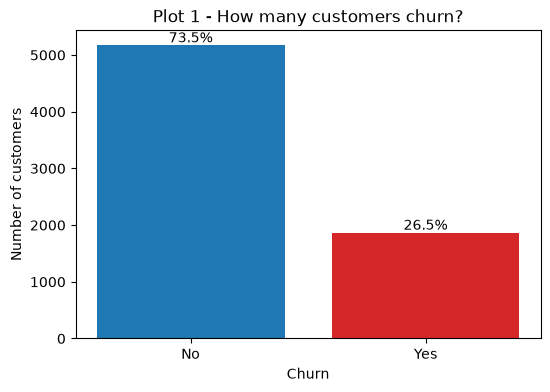

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))                            # one small chart
bars = ax.bar(churn_counts.index, churn_counts.values, color=["tab:blue", "tab:red"])  # one bar per class
for bar, share in zip(bars, churn_share.values):                  # write the percentage on top of each bar
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, f"{share:.1%}", ha="center")  # position + text
ax.set_title("Plot 1 - How many customers churn?")                # chart title
ax.set_xlabel("Churn")                                            # x-axis label
ax.set_ylabel("Number of customers")                              # y-axis label
plt.show()                                                        # draw the chart

**What this cell does:** draws one bar per class with `ax.bar` and writes the share above each bar with `ax.text`.

**What we see:** only about 1 customer in 4 churns (26.5%), so the class we care about is the minority class.

**What I do and why:** Plot 2: I compare the churn rate of the three contract types, because I expect short contracts to be riskier.

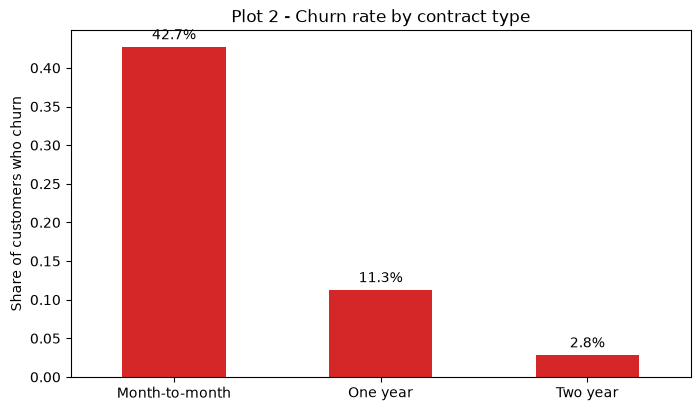

In [8]:
is_churn = df["Churn"] == "Yes"                                   # True for customers who left
churn_by_contract = is_churn.groupby(df["Contract"]).mean().sort_values(ascending=False)  # churn rate per contract type
ax = churn_by_contract.plot(kind="bar", color="tab:red", rot=0)   # bar chart of the three rates
for i, rate in enumerate(churn_by_contract.values):               # label every bar
    ax.text(i, rate + 0.01, f"{rate:.1%}", ha="center")           # the percentage just above the bar
ax.set_title("Plot 2 - Churn rate by contract type")              # chart title
ax.set_xlabel("")                                                 # the category names are enough
ax.set_ylabel("Share of customers who churn")                     # y-axis label
plt.show()                                                        # draw the chart

**What this cell does:** `is_churn` is a True/False column; grouping it by `Contract` and taking the `mean()` gives the **share of churners in each contract type** (the mean of True/False is the share of True).

**What we see:** customers on a month-to-month contract churn far more (42.7%) than those on a one-year (11.3%) or two-year (2.8%) contract — `Contract` will be one of the strongest predictors.

**What I do and why:** Plot 3: I compare how long churners and loyal customers have been with the company.

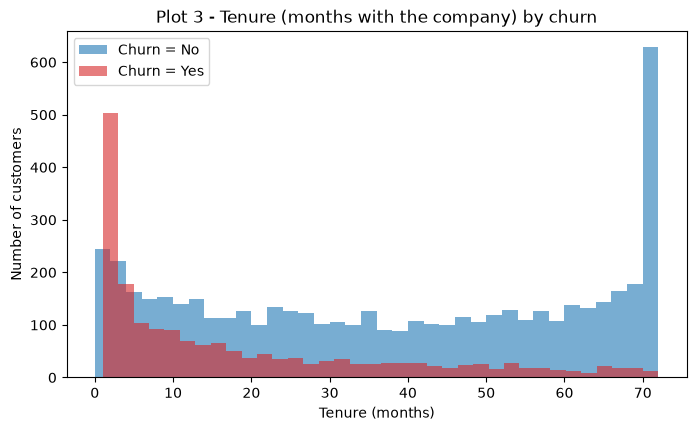

In [9]:
fig, ax = plt.subplots()                                          # one chart
for label, color in [("No", "tab:blue"), ("Yes", "tab:red")]:     # one histogram per class
    ax.hist(df.loc[df["Churn"] == label, "tenure"], bins=36,      # tenure of the customers in this class, 2-month bins
            alpha=0.6, color=color, label=f"Churn = {label}")     # semi-transparent so both are visible
ax.set_title("Plot 3 - Tenure (months with the company) by churn")  # chart title
ax.set_xlabel("Tenure (months)")                                  # x-axis label
ax.set_ylabel("Number of customers")                              # y-axis label
ax.legend()                                                       # explain the two colours
plt.show()                                                        # draw the chart

**What this cell does:** draws two overlapping histograms of `tenure`, one for customers who stayed (blue) and one for those who left (red).

**What we see:** churners are concentrated in the first months (the red bars are highest near 0), while long-standing customers (60+ months) almost never leave — the risk is highest at the start of the relationship, which motivates the `tenure_group` feature in Step 2b.

### 1.5b Extra plots (visual exploration)

The brief asks for 3 plots; these extra ones give a fuller picture of the data before modelling.

**What I do and why:** I look at the churn rate in every category of every text column at once, to find which columns carry signal and which do not.

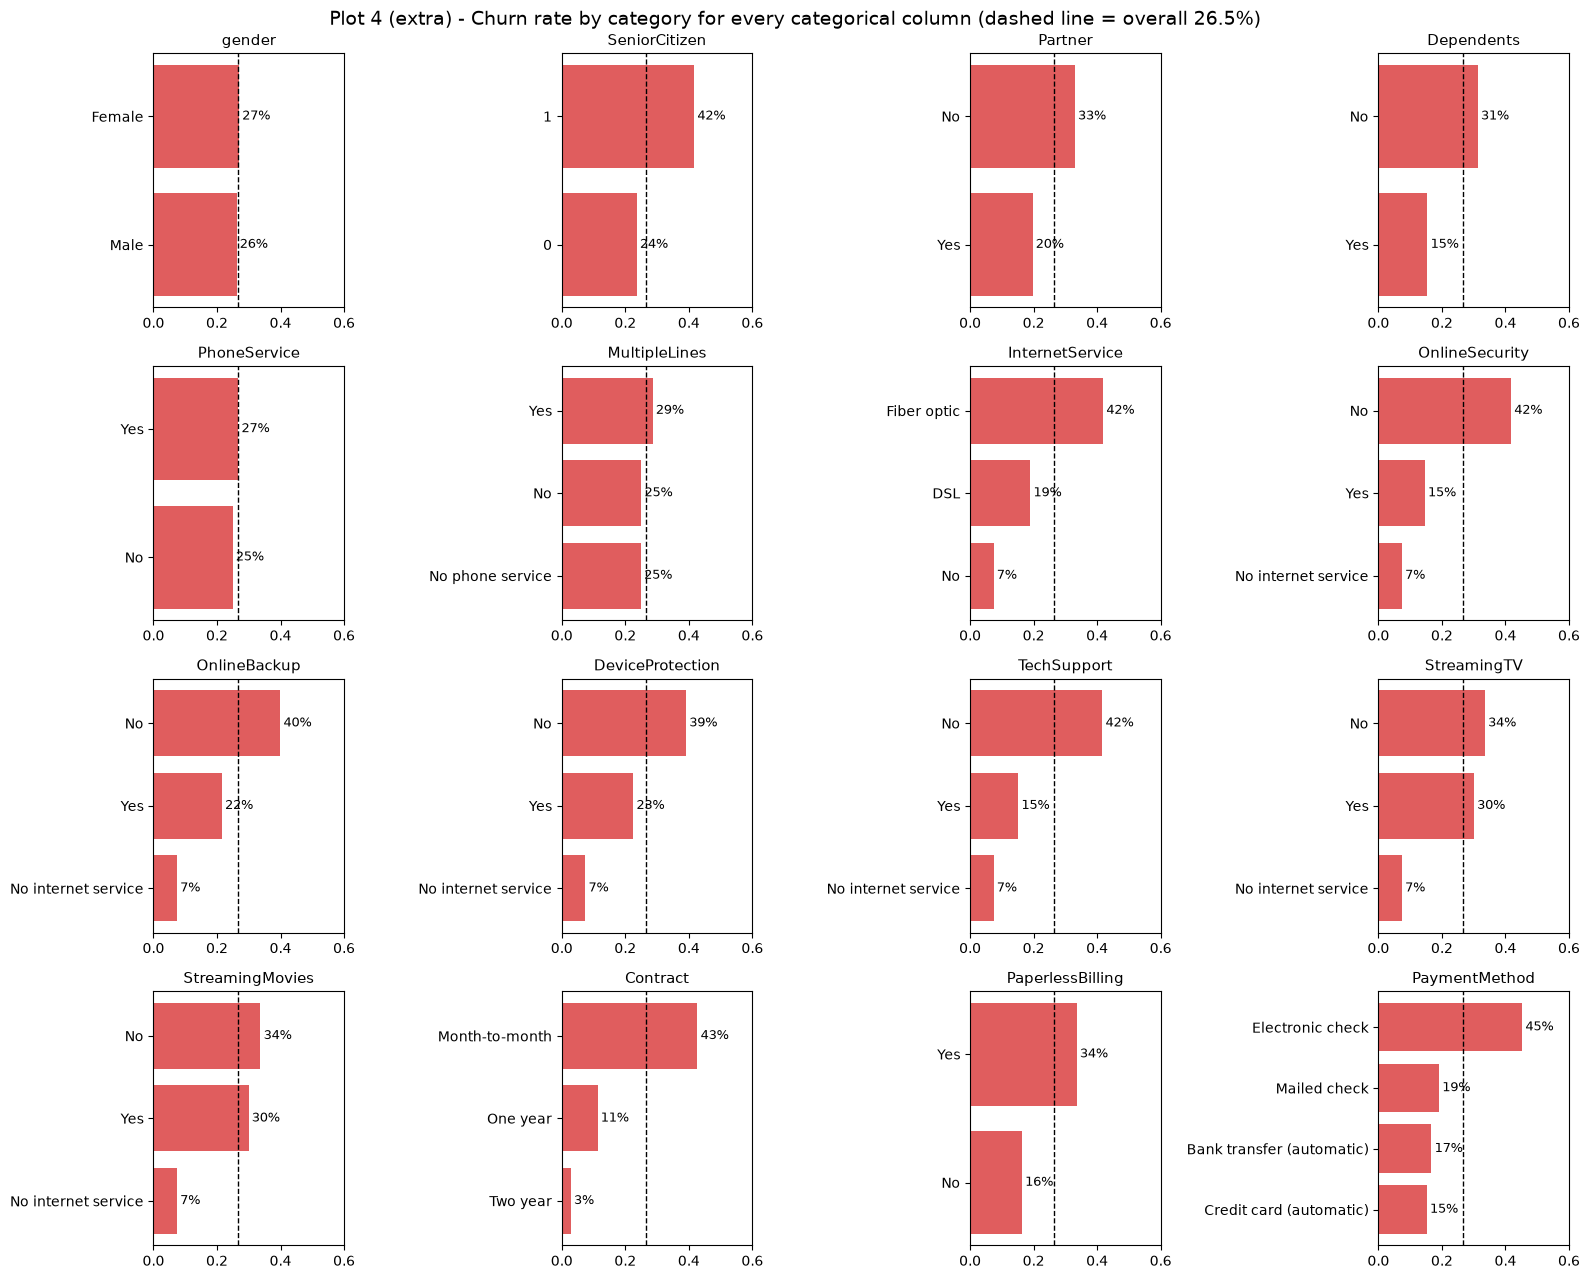

In [10]:
cat_cols = [c for c in df.columns                                         # every categorical column...
            if c not in ("customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn")]  # ...except ID, numbers, target
overall = is_churn.mean()                                                 # overall churn rate (26.5%), the reference line
fig, axes = plt.subplots(4, 4, figsize=(16, 13))                          # a 4 x 4 grid: one small chart per column
for ax, col in zip(axes.ravel(), cat_cols):                               # walk through the grid and the columns together
    rates = is_churn.groupby(df[col]).mean().sort_values()                # churn rate of every category of this column
    ax.barh(rates.index.astype(str), rates.values, color="tab:red", alpha=0.75)  # one horizontal bar per category
    ax.axvline(overall, color="black", linestyle="--", lw=1)              # dashed line = overall churn rate
    for j, v in enumerate(rates.values):                                  # write each rate next to its bar
        ax.text(v + 0.01, j, f"{v:.0%}", va="center", fontsize=9)         # e.g. "42%"
    ax.set_title(col, fontsize=11)                                        # the column name
    ax.set_xlim(0, 0.6)                                                   # same scale on every chart -> easy to compare
fig.suptitle("Plot 4 (extra) - Churn rate by category for every categorical column "
             "(dashed line = overall 26.5%)", fontsize=14)                # one title for the whole grid
plt.tight_layout()                                                        # avoid overlapping labels
plt.show()                                                                # draw it

**What this cell does:** for each of the 16 categorical columns, groups `is_churn` by the column's categories, takes the mean (= churn rate), and draws it as horizontal bars in a 4 × 4 grid (`axes.ravel()` flattens the grid so we can loop over it). The dashed line is the overall churn rate: bars far to the right of it are high-risk groups.

**What we see:** the strongest signals are `Contract` (month-to-month), `PaymentMethod` (electronic check), `InternetService` (fiber optic), the **absence** of `OnlineSecurity` / `TechSupport`, `PaperlessBilling` and `SeniorCitizen`. Some columns barely move away from the line — **`gender` and `PhoneService` have almost the same churn rate in every category**, so they carry little information.

**What I do and why:** I compare the bills of churners and non-churners, to see whether expensive customers leave more often.

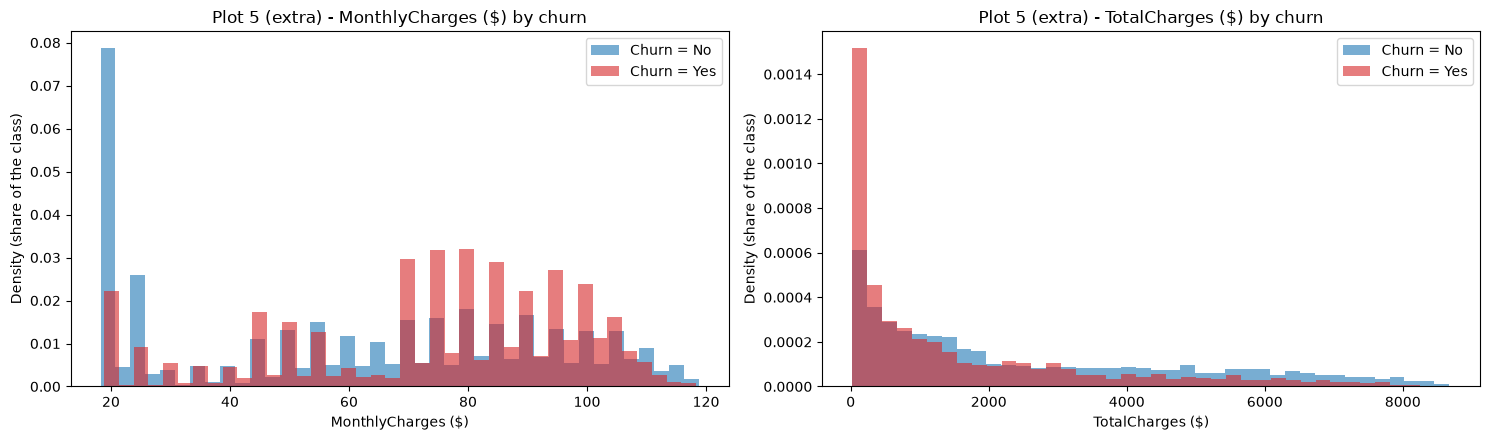

In [11]:
total_num = pd.to_numeric(df["TotalCharges"], errors="coerce")            # text -> number just for this plot (proper cleaning in Step 2)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))                         # two charts side by side
for ax, (title, values) in zip(axes, [("MonthlyCharges ($)", df["MonthlyCharges"]),  # left: the monthly bill
                                      ("TotalCharges ($)", total_num)]):          # right: everything paid so far
    for label, color in [("No", "tab:blue"), ("Yes", "tab:red")]:         # one histogram per class
        ax.hist(values[df["Churn"] == label].dropna(), bins=40, alpha=0.6,  # values of this class (blanks dropped)
                color=color, label=f"Churn = {label}", density=True)      # density=True -> compare shapes, not counts
    ax.set_title(f"Plot 5 (extra) - {title} by churn")                    # chart title
    ax.set_xlabel(title)                                                  # x-axis label
    ax.set_ylabel("Density (share of the class)")                         # y-axis label
    ax.legend()                                                           # explain the colours
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

**What this cell does:** draws the distributions of `MonthlyCharges` and `TotalCharges` for each class. `density=True` rescales each histogram so its area is 1 — this compares the **shapes** of the two classes even though there are almost 3× more non-churners.

**What we see:** churners are concentrated at **high monthly bills (about $70–$105)**, while a big group of loyal customers pays only ~$20 (phone only, no internet). On `TotalCharges` the churners pile up at **low totals** — not because they pay little per month, but because they leave early and never accumulate a large total.

**What I do and why:** I combine tenure and monthly bill in one scatter plot, to see where the churners are.

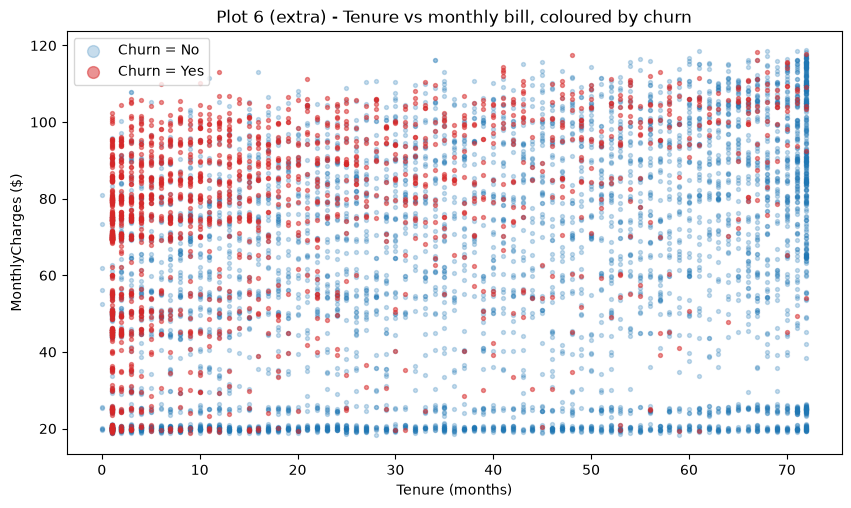

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))                                 # one chart
for label, color, alpha in [("No", "tab:blue", 0.25), ("Yes", "tab:red", 0.5)]:  # stayed first, churned on top
    sub = df[df["Churn"] == label]                                        # customers of this class
    ax.scatter(sub["tenure"], sub["MonthlyCharges"], s=8, c=color,        # one dot per customer
               alpha=alpha, label=f"Churn = {label}")                     # transparency shows dense areas
ax.set_title("Plot 6 (extra) - Tenure vs monthly bill, coloured by churn")  # chart title
ax.set_xlabel("Tenure (months)")                                          # x-axis label
ax.set_ylabel("MonthlyCharges ($)")                                       # y-axis label
ax.legend(markerscale=3)                                                  # bigger dots in the legend
plt.show()                                                                # draw it

**What this cell does:** plots every customer as a dot: x = months with the company, y = monthly bill, colour = churned or not. `alpha` makes the dots semi-transparent so dense areas look darker.

**What we see:** the red dots gather in the **top-left corner** — **new customers with a high bill** — while the right side (long tenure) is almost all blue. The flat band at ~$20 is the phone-only customers, who rarely churn. This two-feature picture already explains a large part of what the models will learn.

### 1.6 What kind of problem is this, and which mistake costs more?

**Classification or regression?** The target `Churn` has two values (Yes / No), so this is **binary classification**. We predict a category, not a number.

**The two possible mistakes:**

| | The model says "will churn" | The model says "will stay" |
|---|---|---|
| **Customer really churns** | ✅ caught (true positive) | ❌ **false negative** — we miss a leaving customer |
| **Customer really stays** | ❌ **false positive** — we contact a happy customer | ✅ correct (true negative) |

* A **false negative** means the company does nothing and loses the customer and all their future monthly payments.
* A **false positive** means the company spends a retention offer (a call, a discount) on someone who would have stayed anyway.

In most telecom businesses losing a customer costs much more than one retention offer, so **false negatives are usually the more expensive mistake**. That is why we will care about **recall** (how many churners we catch), balanced against **precision** (how many of our alarms are real) — see the choice of the main metric in section 2.5.

---
# Step 2 — Prepare the data

### 2.1 Fix the types, the hidden missing values, the ID and the target

All the fixes in this cell are **fixed rules** that do not learn anything from the data (no mean, no statistics), so it is safe to apply them before the train/test split.

**What I do and why:** I fix what I found in the EDA: `TotalCharges` becomes a number (the 11 blanks become 0 because those customers have not paid yet), I drop the ID and I turn the target into 0/1.

In [13]:
data = df.copy()                                                         # work on a copy, keep the raw df untouched
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")  # text -> number; blanks become NaN
print("NaN in TotalCharges after conversion:", data["TotalCharges"].isna().sum())  # the 11 hidden blanks are now visible
data["TotalCharges"] = data["TotalCharges"].fillna(0)                   # tenure 0 -> nothing billed yet -> 0 is the true value
data = data.drop(columns="customerID")                                  # an ID carries no information (and could be memorised)
data["Churn"] = (data["Churn"] == "Yes").astype(int)                    # target as a number: Yes -> 1, No -> 0
print("Shape after cleaning:", data.shape)                              # 1 column fewer (the ID)

NaN in TotalCharges after conversion: 11
Shape after cleaning: (7043, 20)


**What this cell does:** * `pd.to_numeric(..., errors="coerce")` converts `TotalCharges` to numbers; anything that cannot be converted (the 11 blanks) becomes `NaN`, so they finally show up as missing.
* `fillna(0)`: we **fill them with 0 instead of dropping them or using the mean**, because all 11 customers have `tenure = 0` — they have genuinely paid nothing yet, so 0 is the real value, not a guess. (Filling with the mean would invent ~$2,300 of payments for brand-new customers.)
* `drop(columns="customerID")`: an identifier is unique per customer, so it cannot generalise; a model could only memorise it.
* `(data["Churn"] == "Yes").astype(int)` turns the target into 1 (churned) / 0 (stayed), which scikit-learn's metrics expect.

### 2.2 "No internet service" / "No phone service"

Six add-on columns have a third value, `"No internet service"`, and `MultipleLines` has `"No phone service"`. That information already lives in `InternetService` and `PhoneService`, so we merge it into `"No"`.

**What I do and why:** I merge "No internet service" into "No", because that information is already in `InternetService` and it gives me clean yes/no columns.

In [14]:
ADDON_COLS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",      # the 6 internet add-on services
              "TechSupport", "StreamingTV", "StreamingMovies"]
print("Before:", sorted(data["OnlineSecurity"].unique()))               # 3 values: No / No internet service / Yes
data[ADDON_COLS] = data[ADDON_COLS].replace("No internet service", "No")  # no internet -> certainly no add-on
data["MultipleLines"] = data["MultipleLines"].replace("No phone service", "No")  # no phone -> certainly no extra lines
print("After: ", sorted(data["OnlineSecurity"].unique()))               # 2 values now: No / Yes

Before: ['No', 'No internet service', 'Yes']
After:  ['No', 'Yes']


**What this cell does:** `.replace("No internet service", "No")` rewrites the third category in all six add-on columns at once, and the same for `MultipleLines`. Each of those columns becomes a clean yes/no column, which the encoder will turn into **one** 0/1 column instead of three — fewer, clearer columns, and no information lost because `InternetService = "No"` still records who has no internet.

### 2.3 Duplicates

**What I do and why:** I check for duplicate rows and look at them before deciding whether to remove them.

In [15]:
n_dup = data.duplicated().sum()                                          # rows identical to an earlier row, in every column
print("Duplicate rows (after dropping customerID):", n_dup)              # how many there are
dup_rows = data[data.duplicated(keep=False)]                             # every row that has a twin, to inspect them
dup_rows[["tenure", "PhoneService", "InternetService", "Contract", "MonthlyCharges", "TotalCharges", "Churn"]].head(8)  # a sample

Duplicate rows (after dropping customerID): 22


,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
22,1,Yes,No,Month-to-month,20.15,20.15,1
100,1,Yes,No,Month-to-month,20.20,20.20,0
542,1,Yes,No,Month-to-month,19.55,19.55,0
646,1,Yes,DSL,Month-to-month,45.70,45.70,1
662,1,Yes,No,Month-to-month,20.05,20.05,0
690,1,Yes,No,Month-to-month,20.45,20.45,0
964,1,Yes,DSL,Month-to-month,45.70,45.70,1
976,1,Yes,Fiber optic,Month-to-month,69.90,69.90,1


**What this cell does:** `duplicated()` marks rows that are exact copies of an earlier row; `keep=False` marks every member of a duplicate group so we can look at them. There are **22 duplicate rows**, and the sample shows why: they are all brand-new customers (`tenure = 1`) on month-to-month contracts, most of them on the cheapest plan (phone only, no internet, about $20/month). In the original file every one of them had a **different `customerID`**, so these are **different real customers who happen to have identical profiles**, not copy-paste errors. **We keep them**: removing them would under-represent exactly this common type of customer.

### 2.4 Train / test split

We split **before** any scaling, encoding or feature selection that learns from data, and we set the test set aside until Step 5.

**What I do and why:** I split the data 80/20 with `stratify`, before any scaling, and put the test set aside until the very end.

In [16]:
X = data.drop(columns="Churn")                                           # features: everything except the target
y = data["Churn"]                                                        # target: 1 = churned, 0 = stayed

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                                                                # what to split
    test_size=0.2,                                                       # 20% of customers go to the test set
    stratify=y,                                                          # keep the same churn share in both parts
    random_state=RANDOM_STATE,                                           # same split on every run
)
print("Train:", X_train.shape, "| churn share:", round(y_train.mean(), 3))  # size and churn share of the training set
print("Test: ", X_test.shape, "| churn share:", round(y_test.mean(), 3))    # size and churn share of the test set

Train: (5634, 19) | churn share: 0.265
Test:  (1409, 19) | churn share: 0.265


**What this cell does:** `train_test_split` puts **5,634 customers in train and 1,409 in test**. `stratify=y` guarantees that both parts keep the 26.5% churn share (without it, by bad luck, the test set could get noticeably more or fewer churners).

**Why do we split before scaling?** `StandardScaler` *learns* the mean and standard deviation of each column. If it learned them on all the data, the test customers' values would leak into the training preprocessing, and the test set would no longer be truly unseen — the final score would be slightly optimistic. Fitted on the training set only, the test set is transformed with numbers it never influenced, exactly like real future customers. (We go one step further: all learned preprocessing lives **inside a Pipeline**, so it is re-learned inside every cross-validation fold too.)

**What I do and why:** I check visually that both parts have the same churn share.

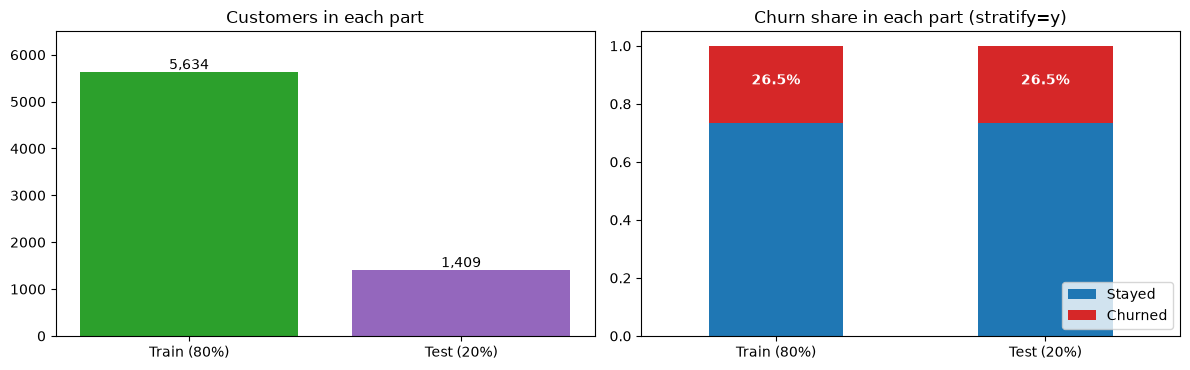

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))                         # two small charts
sizes = pd.Series({"Train (80%)": len(X_train), "Test (20%)": len(X_test)})  # number of customers in each part
axes[0].bar(sizes.index, sizes.values, color=["tab:green", "tab:purple"]) # one bar per part
for i, v in enumerate(sizes.values):                                      # write the count on each bar
    axes[0].text(i, v + 60, f"{v:,}", ha="center")                        # e.g. "5,634"
axes[0].set_title("Customers in each part")                               # chart title
axes[0].set_ylim(0, 6500)                                                 # room for the labels
shares = pd.DataFrame({"Stayed": [1 - y_train.mean(), 1 - y_test.mean()],  # share of each class...
                       "Churned": [y_train.mean(), y_test.mean()]},       # ...in train and in test
                      index=sizes.index)
shares.plot(kind="bar", stacked=True, ax=axes[1], rot=0,                  # stacked bars: the two shares add up to 100%
            color=["tab:blue", "tab:red"])
for i, v in enumerate(shares["Churned"]):                                 # write the churn share
    axes[1].text(i, 1 - v / 2, f"{v:.1%}", ha="center", color="white", fontweight="bold")  # inside the red part
axes[1].set_title("Churn share in each part (stratify=y)")                # chart title
axes[1].legend(loc="lower right")                                         # legend position
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

**What this cell does:** left: the number of customers in train and test (`len`). Right: a stacked bar of the share of stayed/churned customers in each part. Thanks to `stratify=y` the red part is **26.5% in both** — the test set is a faithful miniature of the training set.

### 2.5 Cross-validation setup and the main metric

**Main metric: F1 score of the churn class.**
* **Accuracy** is misleading here: "always No" already scores 73.5% while catching zero churners.
* **Recall** alone could be maximised by flagging everyone as a churner (100% recall, useless precision).
* **F1** is the harmonic mean of precision and recall: it is only high when we catch many churners (recall) **and** most alarms are real (precision). It fits the cost analysis in 1.6 — missing churners is expensive, but contacting every customer is not free either.

We also report **recall**, **precision**, **ROC-AUC** and **PR-AUC** (area under the precision-recall curve, informative when positives are rare) so the picture is complete.

**What I do and why:** I prepare 5-fold stratified cross-validation and a helper that returns all my metrics, so I can compare models fairly using only the training set.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # 5 folds, same churn share in each

SCORING = {                                                              # every metric we want from each CV run
    "accuracy": "accuracy",                                              # share of correct predictions
    "precision": make_scorer(precision_score, zero_division=0),         # of predicted churners, share that really churn
    "recall": "recall",                                                  # of real churners, share we catch
    "f1": "f1",                                                          # balance of precision and recall -> MAIN metric
    "roc_auc": "roc_auc",                                                # how well churners are ranked above non-churners
    "pr_auc": "average_precision",                                       # area under the precision-recall curve
}


def cv_report(pipe, n_jobs=-1):
    """Cross-validate a pipeline on the training set and return the mean of every metric."""
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=n_jobs)  # 5 fits, all metrics
    scores = {m: res[f"test_{m}"].mean() for m in SCORING}              # mean over the 5 folds for each metric
    scores["f1_std"] = res["test_f1"].std()                             # how much F1 varies between folds
    return scores                                                        # one dictionary per model


print("CV ready:", cv)                                                   # confirmation

CV ready: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


**What this cell does:** `StratifiedKFold(5, shuffle=True)` cuts the training set into 5 folds that each keep the 26.5% churn share. `SCORING` lists the six metrics; `precision` is wrapped in `make_scorer(..., zero_division=0)` so a model that never predicts "churn" (the dummy) gets 0 instead of a warning. `cv_report` runs `cross_validate` — 5 fits, each validated on the fold it did not see — and returns the **mean** of each metric plus the **standard deviation of F1**, which tells us how much of a difference between models could just be luck. `n_jobs=-1` runs the folds in parallel on all CPU cores. The test set is never used here.

**How 5-fold stratified cross-validation works (picture):**

**What I do and why:** I draw how cross-validation splits the training data, so I can explain it in my presentation.

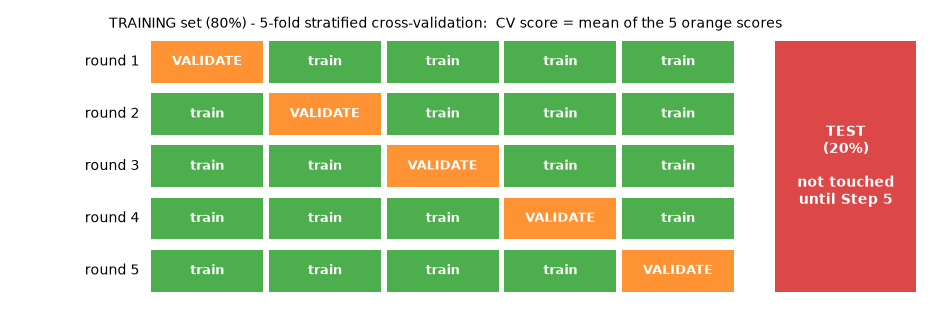

In [19]:
fig, ax = plt.subplots(figsize=(12, 3.8))                                 # one canvas
for fold in range(5):                                                     # one row per CV round
    for part in range(5):                                                 # the 5 parts of the training set
        is_val = part == fold                                             # in round k, part k is the validation part
        ax.add_patch(plt.Rectangle((part, 4 - fold), 0.95, 0.8,           # one block
                                   facecolor="tab:orange" if is_val else "tab:green", alpha=0.85))
        ax.text(part + 0.475, 4 - fold + 0.4, "VALIDATE" if is_val else "train",  # its label
                ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    ax.text(-0.1, 4 - fold + 0.4, f"round {fold + 1}", ha="right", va="center")  # row label
ax.add_patch(plt.Rectangle((5.3, 0), 1.2, 4.8, facecolor="tab:red", alpha=0.85))  # the test set, outside the CV
ax.text(5.9, 2.4, "TEST\n(20%)\n\nnot touched\nuntil Step 5", ha="center", va="center",  # its label
        color="white", fontweight="bold")
ax.text(2.5, 5.05, "TRAINING set (80%) - 5-fold stratified cross-validation:  CV score = mean of the 5 orange scores",
        ha="center")                                                      # caption above the grid
ax.set_xlim(-1.2, 6.7)                                                    # room for the row labels
ax.set_ylim(-0.2, 5.4)                                                    # room for the caption
ax.axis("off")                                                            # it is a diagram
plt.show()                                                                # draw it

**What this cell does:** draws the 5 rounds of cross-validation: in each round the model is trained on the 4 green parts and scored on the orange part, so **every training customer is used for validation exactly once**. The CV score is the mean of the 5 orange scores, and their spread (standard deviation) shows how much is luck. The red block — the test set — stays outside the whole process.

---
# Step 2b — Feature engineering: the 6-tool toolkit

The course's toolkit (Session 13, see `reference/feature_engineering_toolkit.png`) and how each tool is used on Telco:

| # | Tool | What it does | What we build here |
|---|---|---|---|
| 1 | **Encoding** | text → numbers | `OneHotEncoder` for every category (yes/no columns become a single 0/1 column); **ordinal** `contract_months` (0 < 12 < 24) because contracts have a natural order |
| 2 | **Scaling** | same scale for all | `StandardScaler` on every numeric column — Step 2c is dedicated to it |
| 3 | **Binning** | numbers → intervals | `tenure_group`: 0–6, 7–24, 25+ months (the first months are the riskiest, Plot 3) |
| 4 | **Ratios & interactions** | combine two columns | `avg_monthly = TotalCharges / tenure`, `charge_increase = MonthlyCharges − avg_monthly`, `price_per_service`, `has_family` (Partner **or** Dependents) |
| 5 | **Aggregations** | summarise many columns / a history | `num_services` (how many of the 9 services the customer has), `num_protection` (how many of the 4 security/support add-ons) |
| 6 | **Calendar dates** | extract day, month, weekend… | **not applicable** — Telco has no date column. `tenure` already plays the "time since signing" role. |

All new features are computed **row by row with fixed rules** (no statistics learned from other customers), so they cannot leak information. We still put the function inside the Pipeline with `FunctionTransformer`, so the exact same transformation is applied automatically to training folds, validation folds, the test set and any future customer.

**What I do and why:** I create 8 new features with the course's feature engineering toolkit (ratios, counts, bins, ordinal encoding), using fixed rules so nothing leaks from other customers.

In [20]:
SERVICE_COLS = ["PhoneService", "MultipleLines"] + ADDON_COLS            # 8 yes/no service columns (+ internet = 9 services)
PROTECTION_COLS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]  # security / support add-ons
CONTRACT_MONTHS = {"Month-to-month": 0, "One year": 12, "Two year": 24}  # ordinal encoding: months of commitment


def add_features(X):
    """Return a copy of X with the engineered columns added (fixed rules, nothing learned from data)."""
    X = X.copy()                                                         # never modify the caller's DataFrame

    # Tool 4 - ratios: the real average monthly bill over the whole relationship
    months = X["tenure"].replace(0, np.nan)                              # tenure 0 would divide by zero -> NaN
    X["avg_monthly"] = (X["TotalCharges"] / months).fillna(X["MonthlyCharges"])  # new customers: use today's bill
    X["charge_increase"] = X["MonthlyCharges"] - X["avg_monthly"]       # > 0: the bill went up recently

    # Tool 5 - aggregations: how "attached" the customer is to the company
    X["num_services"] = (X[SERVICE_COLS] == "Yes").sum(axis=1) + (X["InternetService"] != "No").astype(int)  # 1..9
    X["num_protection"] = (X[PROTECTION_COLS] == "Yes").sum(axis=1)      # 0..4 security / support add-ons

    # Tool 4 - ratio + interaction
    services = X["num_services"].replace(0, np.nan)                      # guard: 0 services would divide by zero
    X["price_per_service"] = (X["MonthlyCharges"] / services).fillna(X["MonthlyCharges"])  # cost of each service
    X["has_family"] = ((X["Partner"] == "Yes") | (X["Dependents"] == "Yes")).astype(int)  # partner OR dependents

    # Tool 3 - binning: tenure into risk intervals (fixed thresholds from the course slide)
    X["tenure_group"] = pd.cut(X["tenure"], bins=[-1, 6, 24, np.inf],    # (-1,6] (6,24] (24,inf)
                               labels=["0-6", "7-24", "25+"]).astype(str)  # text labels, one-hot encoded later

    # Tool 1 - ordinal encoding: contracts have a natural order
    X["contract_months"] = X["Contract"].map(CONTRACT_MONTHS)            # 0 / 12 / 24
    return X                                                             # original columns + 8 new ones


NEW_FEATURES = ["avg_monthly", "charge_increase", "num_services", "num_protection",
                "price_per_service", "has_family", "tenure_group", "contract_months"]  # for display below
print("Feature function defined:", len(NEW_FEATURES), "new columns")    # confirmation

Feature function defined: 8 new columns


**What this cell does:** defines `add_features`, which receives a table of customers and returns it with **8 new columns**:
* `avg_monthly`: `TotalCharges / tenure`, the true average bill; for `tenure = 0` (division by zero) it falls back to today's `MonthlyCharges`.
* `charge_increase`: today's bill minus the historical average — positive if the customer's price went up, a classic churn trigger.
* `num_services` / `num_protection`: `(X[cols] == "Yes").sum(axis=1)` counts the "Yes" answers across columns for each row (`axis=1` = across the row); internet counts as one more service.
* `price_per_service`: what each service costs the customer. In the real data every customer has at least one service, but the division is still guarded (0 → `NaN` → today's bill): a strange new customer — or the column shuffling in bonus B2 — must never produce an infinite value that crashes the model.
* `has_family`: `|` is a row-wise OR — 1 if the customer has a partner or dependents.
* `tenure_group`: `pd.cut` puts each tenure in an interval: `(-1, 6]` = 0–6 months, `(6, 24]` = 7–24, `(24, inf)` = 25+.
* `contract_months`: `.map` replaces each contract name by its number of months (ordinal encoding).

**A look at the new features (training set only).** Before trusting them, we check on the training data whether they actually separate churners from non-churners.

**What I do and why:** I check, on the training set only, whether the new features really separate churners from non-churners.

In [21]:
train_fe = add_features(X_train)                                         # engineered version of the TRAINING set only
train_fe["Churn"] = y_train                                              # attach the target to compute churn rates

for col in ["tenure_group", "num_services", "contract_months"]:          # three of the new columns
    rates = train_fe.groupby(col)["Churn"].agg(["mean", "size"])         # churn rate and number of customers per value
    if col == "tenure_group":                                            # text labels sort alphabetically...
        rates = rates.reindex(["0-6", "7-24", "25+"])                    # ...so put them back in their natural order
    rates.columns = ["churn_rate", "customers"]                          # readable column names
    print(f"\n--- {col} ---")                                           # header
    print(rates.round(3).to_string())                                    # the table as text

train_fe[NEW_FEATURES].head()                                            # first rows of the new columns


--- tenure_group ---
              churn_rate  customers
tenure_group                       
0-6                0.522       1170
7-24               0.321       1385
25+                0.143       3079

--- num_services ---
              churn_rate  customers
num_services                       
1                  0.105        998
2                  0.310        704
3                  0.439        645
4                  0.367        777
5                  0.325        741
6                  0.261        724
7                  0.230        552
8                  0.122        319
9                  0.046        174

--- contract_months ---
                 churn_rate  customers
contract_months                       
0                     0.427       3102
12                    0.111       1173
24                    0.029       1359


,avg_monthly,charge_increase,num_services,num_protection,price_per_service,has_family,tenure_group,contract_months
3738,48.618571,0.581429,4,1,12.300000,0,25+,0
3151,76.770000,-1.670000,3,1,25.033333,1,7-24,0
4860,45.411538,-4.861538,4,3,10.137500,1,7-24,24
3867,73.296154,0.203846,6,2,12.250000,1,25+,24
3810,44.550000,0.000000,2,0,22.275000,1,0-6,0


**What this cell does:** applies `add_features` to `X_train` only (never to the test set at this stage), then uses `groupby(...).agg(["mean", "size"])` to show the churn rate and the number of customers for each value of three new features. The binning works as intended — the churn rate falls steadily from the `0-6` group to the `25+` group — and `contract_months` shows the same strong ordering as Plot 2. `num_services` is less clear-cut: churn is low for customers with a single service (mostly phone-only, cheap plans), peaks in the middle, and falls again for customers with many services. A linear model cannot draw such a "rise then fall" shape from the raw columns on its own, which is exactly what a feature like this is for. Whether these features improve the **score** is measured honestly in Step 4.2.

**What I do and why:** I show the same check as bar charts.

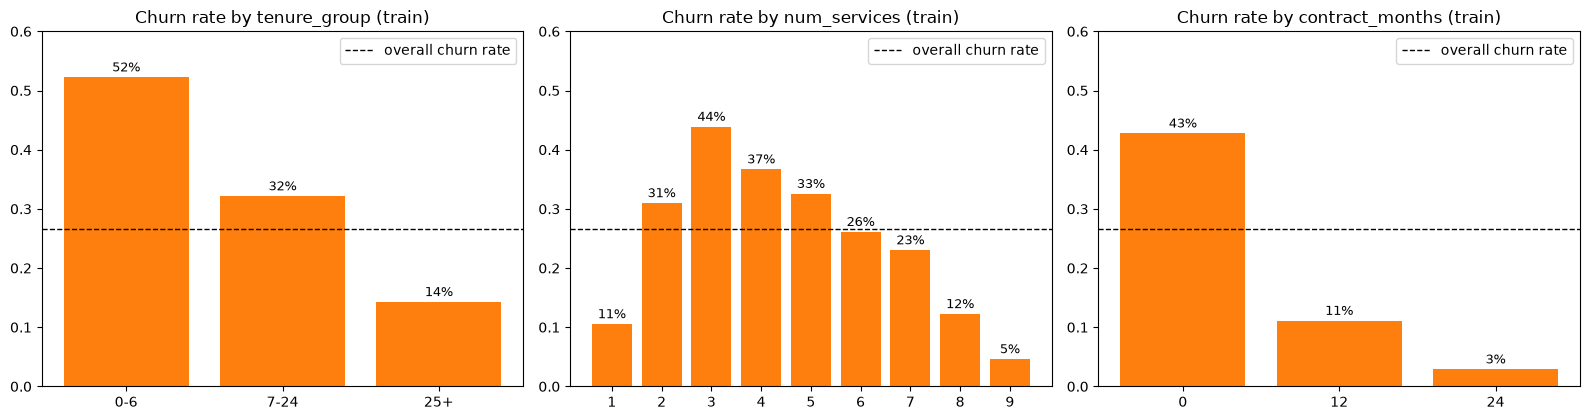

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))                         # three charts side by side
for ax, col in zip(axes, ["tenure_group", "num_services", "contract_months"]):  # three engineered features
    rates = train_fe.groupby(col)["Churn"].mean()                         # churn rate for each value
    if col == "tenure_group":                                             # natural order instead of alphabetical
        rates = rates.reindex(["0-6", "7-24", "25+"])
    ax.bar(rates.index.astype(str), rates.values, color="tab:orange")     # one bar per value
    ax.axhline(y_train.mean(), color="black", linestyle="--", lw=1, label="overall churn rate")  # reference line
    for i, v in enumerate(rates.values):                                  # write each rate above its bar
        ax.text(i, v + 0.01, f"{v:.0%}", ha="center", fontsize=9)
    ax.set_title(f"Churn rate by {col} (train)")                          # chart title
    ax.set_ylim(0, 0.6)                                                   # same scale on all three
    ax.legend(loc="upper right")                                          # legend
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

**What this cell does:** draws the same three churn-rate tables as bar charts. The **staircase** of `tenure_group` (52% → 32% → 14%) and `contract_months` (43% → 11% → 3%) is the pattern the binning and the ordinal encoding were designed to capture; the **hump** of `num_services` (low at 1 service, peak at 3, very low at 8–9) shows a non-linear effect that a single raw column could not express.

**Leakage check — the "too good" feature (Session 13).** For every column we ask the control question: *would I have this information at the moment I make the prediction?* All Telco columns describe the customer's current profile, services and billing — nothing is recorded **after** the churn decision (no cancellation request, no reason for leaving, no cancellation date). `customerID` was dropped in 2.1. So there is no leakage column here; Step 5's feature-importance section double-checks that no single column dominates suspiciously.

**Column lists and the pipeline builder.** Raw features = the original 19 columns; engineered = the original 19 + the 8 new ones. Numeric columns get `StandardScaler`, categorical columns get `OneHotEncoder`.

**What I do and why:** I build one pipeline function (features → scaling + encoding → model), so every model gets exactly the same preprocessing, re-fitted inside every CV fold.

In [23]:
NUM_RAW = ["tenure", "MonthlyCharges", "TotalCharges"]                  # the 3 truly numeric original columns
CAT_RAW = [c for c in X.columns if c not in NUM_RAW]                     # the other 16 original columns (incl. SeniorCitizen 0/1)
NUM_FE = NUM_RAW + ["avg_monthly", "charge_increase", "num_services",   # numeric columns after feature engineering
                    "num_protection", "price_per_service", "contract_months"]
CAT_FE = CAT_RAW + ["has_family", "tenure_group"]                       # categorical columns after feature engineering


def make_preprocessor(num_cols, cat_cols, scale=True):
    """Scale the numeric columns (optional) and one-hot encode the categorical ones."""
    return ColumnTransformer([
        ("num", StandardScaler() if scale else "passthrough", num_cols),  # scaling ON or OFF (for the experiments)
        ("cat", OneHotEncoder(handle_unknown="ignore",                  # unseen category -> all zeros, not an error
                              drop="if_binary",                         # yes/no columns -> a single 0/1 column
                              sparse_output=False), cat_cols),          # a normal dense array
    ])


def build_pipeline(model, engineered=True, scale=True):
    """features (optional) -> preprocessing -> model, all fitted together inside CV."""
    steps = []                                                           # the list of pipeline steps
    if engineered:                                                       # engineered version: add our 8 columns first
        steps.append(("features", FunctionTransformer(add_features)))   # our own function as a pipeline step
        steps.append(("prep", make_preprocessor(NUM_FE, CAT_FE, scale)))  # preprocessing of all 27 columns
    else:                                                                # raw version: original columns only
        steps.append(("prep", make_preprocessor(NUM_RAW, CAT_RAW, scale)))  # preprocessing of the 19 columns
    steps.append(("model", model))                                       # the estimator is always the last step
    return Pipeline(steps)                                               # one object: fit / predict / CV / tuning


demo = build_pipeline(LogisticRegression()).fit(X_train, y_train)       # fit once just to count the final columns
print("Columns the model sees (engineered):", len(demo.named_steps["prep"].get_feature_names_out()))  # after encoding
demo_raw = build_pipeline(LogisticRegression(), engineered=False).fit(X_train, y_train)  # same, raw features
print("Columns the model sees (raw):       ", len(demo_raw.named_steps["prep"].get_feature_names_out()))

Columns the model sees (engineered): 36
Columns the model sees (raw):        26


**What this cell does:** * `make_preprocessor` builds a `ColumnTransformer`: `StandardScaler` on the numeric columns (or `"passthrough"` = unchanged, used only in the scaling experiments) and `OneHotEncoder` on the categorical ones. `drop="if_binary"` turns every yes/no column into one 0/1 column (tool 1, encoding) instead of two redundant ones; `handle_unknown="ignore"` avoids a crash if the test set contains a category never seen in training.
* `build_pipeline` chains `add_features` (wrapped in `FunctionTransformer`) → preprocessing → model into one `Pipeline`. When a pipeline is cross-validated or tuned, **every step is re-fitted on the training part of each fold only** — this is what prevents leakage.
* The last lines fit two demo pipelines and count the final columns: **26** with raw features and **36** with engineered features (after one-hot encoding).

**The pipeline as a diagram.** A fitted scikit-learn `Pipeline` draws itself in Jupyter; click a box to see its settings.

**What I do and why:** I display my pipeline as a diagram to see all its steps.

In [24]:
demo   # the demo pipeline from the previous cell: features -> (scaler | one-hot encoder) -> model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('prep', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x705dd893de40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


**What this cell does:** evaluating a pipeline object as the last line of a cell makes Jupyter show scikit-learn's **interactive diagram**: `FunctionTransformer(add_features)` → a `ColumnTransformer` that splits into two branches (`StandardScaler` on the numeric columns, `OneHotEncoder` on the categorical ones) → the model. In Jupyter you can click each box to expand its parameters and column lists. (On GitHub only the text version may be shown.)

---
# Step 2c — Scaling: the main focus

### 2c.1 The problem: very different scales

**What I do and why:** I compare the ranges of the numeric columns to show why scaling is needed.

In [25]:
train_fe[NUM_FE].describe().T[["mean", "std", "min", "max"]].round(1)   # spread of every numeric column (training set)

,mean,std,min,max
tenure,32.5,24.6,0.0,72.0
MonthlyCharges,64.9,30.1,18.4,118.8
TotalCharges,2299.3,2279.2,0.0,8684.8
avg_monthly,64.9,30.2,13.8,121.4
charge_increase,-0.0,2.6,-18.9,19.1
num_services,4.2,2.3,1.0,9.0
num_protection,1.3,1.3,0.0,4.0
price_per_service,17.2,5.4,8.6,35.9
contract_months,8.3,10.0,0.0,24.0


**What this cell does:** `describe()` computes summary statistics; `.T` transposes so each column is a row, and we keep mean, standard deviation, min and max. **`TotalCharges` goes up to ~8,700 with a standard deviation of ~2,280**, while `num_protection` goes from 0 to 4 and `charge_increase` has a standard deviation under 3. Any model that measures **distances** (SVM, kNN, k-Means) or is trained by **gradient steps on weighted sums** (logistic regression) would be dominated by `TotalCharges` just because of its units (dollars vs counts), not because it matters more.

### 2c.2 The fix: `StandardScaler`, fitted on the training set only

`StandardScaler` transforms every column into `(value − mean) / standard deviation`, so each column ends up with mean 0 and standard deviation 1. It **learns** the mean and the standard deviation — so it must learn them on the training data only.

**What I do and why:** I fit the scaler on the training set only and apply it to the test set, to prove that the test data does not influence it.

In [26]:
scaler = StandardScaler()                                                # create the scaler
train_scaled = scaler.fit_transform(add_features(X_train)[NUM_FE])      # LEARN mean/std on train, then transform train
test_scaled = scaler.transform(add_features(X_test)[NUM_FE])            # REUSE the train mean/std on the test set

summary = pd.DataFrame({                                                 # compare the result on both sets
    "train mean": train_scaled.mean(axis=0),                             # exactly 0 on train (by construction)
    "train std": train_scaled.std(axis=0),                               # exactly 1 on train
    "test mean": test_scaled.mean(axis=0),                               # close to 0 but NOT exactly: never seen by the scaler
    "test std": test_scaled.std(axis=0),                                 # close to 1 but NOT exactly
}, index=NUM_FE)
summary.round(3)                                                         # show the table

,train mean,train std,test mean,test std
tenure,-0.0,1.0,-0.023,0.998
MonthlyCharges,-0.0,1.0,-0.028,0.992
TotalCharges,0.0,1.0,-0.043,0.972
avg_monthly,-0.0,1.0,-0.029,0.994
charge_increase,-0.0,1.0,0.013,1.030
num_services,-0.0,1.0,-0.046,0.981
num_protection,-0.0,1.0,-0.046,0.994
price_per_service,0.0,1.0,0.042,1.016
contract_months,-0.0,1.0,-0.001,0.996


**What this cell does:** `fit_transform` on the training set **learns** each column's mean and standard deviation and applies them; `transform` on the test set **reuses** those training numbers without learning anything new. The table shows the proof: on train every column has mean **exactly 0** and standard deviation **exactly 1**; on test they are only **close** to 0 and 1, because the test customers did not influence the scaler — exactly how it will behave on future, real customers. (This standalone scaler is only for the demonstration; in the models the scaler lives inside the Pipeline.)

**Why we do not scale the one-hot columns:** they are already 0/1 — a small, comparable scale — and leaving them as 0/1 keeps them readable ("has this service or not"). One-hot columns are only passed through the encoder.

**What I do and why:** I show the numeric columns before and after scaling, side by side.

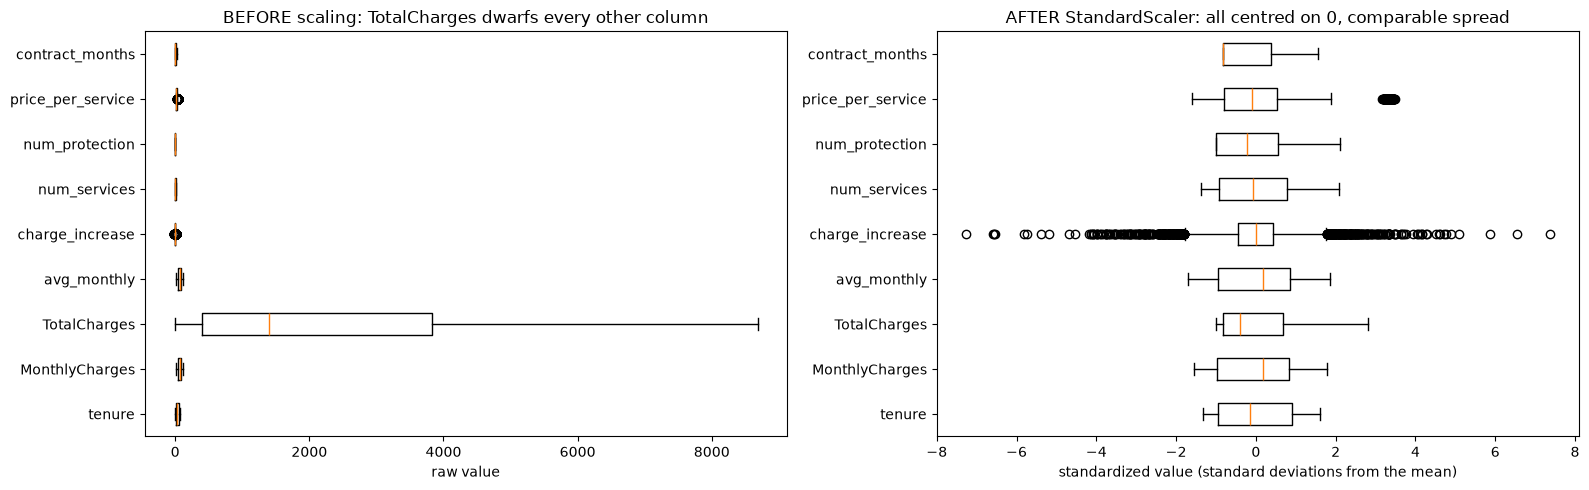

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))                           # before / after, side by side
axes[0].boxplot([train_fe[c] for c in NUM_FE], tick_labels=NUM_FE,        # one box per numeric column, raw values
                orientation="horizontal")
axes[0].set_title("BEFORE scaling: TotalCharges dwarfs every other column")  # chart title
axes[0].set_xlabel("raw value")                                           # x-axis label
axes[1].boxplot([train_scaled[:, i] for i in range(len(NUM_FE))],         # the same columns after StandardScaler
                tick_labels=NUM_FE, orientation="horizontal")
axes[1].set_title("AFTER StandardScaler: all centred on 0, comparable spread")  # chart title
axes[1].set_xlabel("standardized value (standard deviations from the mean)")    # x-axis label
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

**What this cell does:** draws a box plot per numeric column (the box = middle 50% of customers, the line inside = median, the whiskers/dots = the spread and outliers), first with the raw values and then with the standardized values from the previous cell. **Before:** `TotalCharges` stretches to ~8,700 and squashes every other column into an invisible sliver near 0. **After:** every column is centred on 0 and spread over a few units, so no column dominates distance or gradient calculations just because of its units.

### 2c.3 Experiment 1 — logistic regression with vs without scaling

Same model, same features, same folds; the only difference is the `StandardScaler` step. We use the default `max_iter=100` (the solver's maximum number of steps) to see whether it converges.

**What I do and why:** Experiment: the same logistic regression with and without scaling, to see whether scaling matters for this model.

In [28]:
rows = []                                                                # one result row per setting
for scale in [False, True]:                                              # without scaling, then with scaling
    pipe = build_pipeline(LogisticRegression(max_iter=100), scale=scale) # default solver budget: 100 iterations
    with warnings.catch_warnings(record=True) as caught:                 # record the warnings instead of printing them
        warnings.simplefilter("always")                                  # make sure every warning is recorded
        pipe.fit(X_train, y_train)                                       # fit once on the whole training set
    n_conv = sum(issubclass(w.category, ConvergenceWarning) for w in caught)  # did the solver give up?
    with warnings.catch_warnings():                                      # silence the same warning during CV
        warnings.simplefilter("ignore")                                  # (we already counted it above)
        f1_cv = cv_report(pipe, n_jobs=1)["f1"]                          # 5-fold F1 (run in this process so warnings stay hidden)
    rows.append({"scaling": "StandardScaler" if scale else "none",       # store the result
                 "solver iterations": int(pipe.named_steps["model"].n_iter_[0]),  # steps the solver needed
                 "ConvergenceWarning": "yes" if n_conv else "no",        # stopped before converging?
                 "CV F1": round(f1_cv, 3)})                              # cross-validated F1
lr_scaling = pd.DataFrame(rows)                                          # keep the table for the summary chart
lr_scaling                                                               # show it

,scaling,solver iterations,ConvergenceWarning,CV F1
0,none,100,yes,0.577
1,StandardScaler,54,no,0.596


**What this cell does:** fits the same logistic regression twice, once with `"passthrough"` (no scaling) and once with `StandardScaler`. `warnings.catch_warnings(record=True)` collects warnings in a list so we can count `ConvergenceWarning`s; `n_iter_` tells how many steps the solver used.

**Result:** without scaling the solver **hits the 100-iteration limit and raises a `ConvergenceWarning`** — it stops before finding the best coefficients, and the CV F1 is lower (**0.577 vs 0.596**). With scaling it converges in about half the steps. The reason: the gradient steps are dominated by the huge `TotalCharges` values, so the small-scale columns are learned very slowly. A second benefit: after scaling, the coefficients are **comparable to each other** (one unit = one standard deviation for every column), which lets us read which features push churn up or down (bonus section B3).

### 2c.4 Experiment 2 — trees don't care, SVM cares a lot

**What I do and why:** Experiment: Random Forest and SVM with and without scaling, to show which models need it and which do not.

In [29]:
neg, pos = np.bincount(y_train)                                          # number of non-churners and churners in train
experiments = {                                                          # one tree model, one distance-based model
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=1),
    "SVM (RBF kernel)": SVC(class_weight="balanced", random_state=RANDOM_STATE),
}
rows = []                                                                # one row per model
for name, model in experiments.items():                                  # loop over the two models
    f1_raw = cv_report(build_pipeline(clone(model), scale=False))["f1"]  # CV F1 without scaling
    f1_scaled = cv_report(build_pipeline(clone(model), scale=True))["f1"]  # CV F1 with scaling
    rows.append({"model": name, "F1 without scaling": round(f1_raw, 3),  # store both results
                 "F1 with scaling": round(f1_scaled, 3), "difference": round(f1_scaled - f1_raw, 3)})
other_scaling = pd.DataFrame(rows)                                       # keep the table for the summary chart
other_scaling                                                            # show it

,model,F1 without scaling,F1 with scaling,difference
0,Random Forest,0.615,0.616,0.000
1,SVM (RBF kernel),0.495,0.626,0.131


**What this cell does:** runs 5-fold CV for a Random Forest and an SVM, each with and without `StandardScaler`. `np.bincount(y_train)` counts the 0s and 1s in the target (used later for XGBoost). `clone(model)` gives a fresh, unfitted copy each time.

**Result:**
* **Random Forest: practically no difference** (0.615 vs 0.616). A tree splits on **one column at a time** with a threshold ("`tenure` < 6.5?"); multiplying or shifting a column moves the threshold but not which customers end up on each side.
* **SVM: a huge difference** (about **0.50 → 0.63**). The RBF kernel compares customers by their **distance**, and without scaling that distance is almost entirely `TotalCharges`; with scaling every column counts.

**Summary of the scaling lesson:**

| Model | Needs scaling? | Why |
|---|---|---|
| Logistic regression | **yes** | gradient-based training converges badly; coefficients only comparable after scaling |
| SVM, kNN, k-Means, PCA | **yes, absolutely** | they use distances / variances, dominated by the largest-unit column |
| Decision tree, Random Forest, XGBoost | no (harmless) | one-column threshold splits do not depend on the scale |

We keep `StandardScaler` in **every** pipeline: it is required for two of our models and harmless for the other two, and it keeps all four comparisons identical.

**What I do and why:** I put the three scaling experiments in one chart.

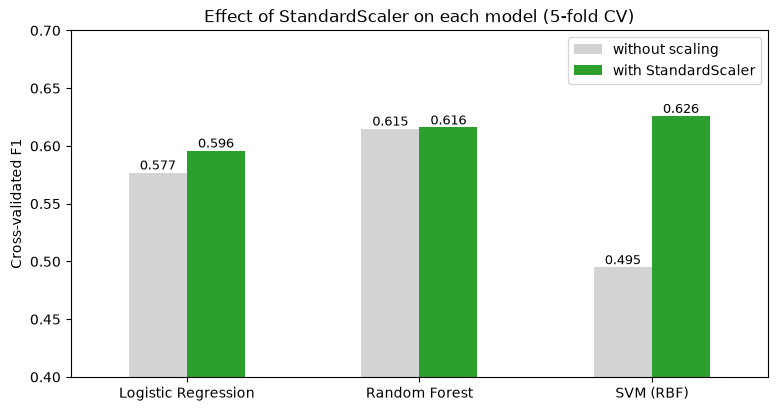

In [30]:
scaling_summary = pd.DataFrame({                                          # the three experiments in one table
    "without scaling": [lr_scaling.loc[0, "CV F1"],                       # logistic regression, no scaler
                        other_scaling.loc[0, "F1 without scaling"],       # Random Forest, no scaler
                        other_scaling.loc[1, "F1 without scaling"]],      # SVM, no scaler
    "with StandardScaler": [lr_scaling.loc[1, "CV F1"],                   # logistic regression, scaled
                            other_scaling.loc[0, "F1 with scaling"],      # Random Forest, scaled
                            other_scaling.loc[1, "F1 with scaling"]],     # SVM, scaled
}, index=["Logistic Regression", "Random Forest", "SVM (RBF)"])
ax = scaling_summary.plot(kind="bar", rot=0, figsize=(9, 4.5),            # grouped bars: grey = raw, green = scaled
                          color=["lightgray", "tab:green"])
for container in ax.containers:                                           # write the value on every bar
    ax.bar_label(container, fmt="%.3f", fontsize=9)
ax.set_ylim(0.4, 0.7)                                                     # zoom on the interesting range
ax.set_ylabel("Cross-validated F1")                                       # y-axis label
ax.set_title("Effect of StandardScaler on each model (5-fold CV)")        # chart title
plt.show()                                                                # draw it

**What this cell does:** collects the three scaling experiments into one table and draws grouped bars (`ax.bar_label` writes the values on the bars). The picture says it all: scaling **helps logistic regression, is essential for the SVM, and changes nothing for the Random Forest**. (The logistic regression here has no class weighting, which is why its F1 is a bit lower than the SVM's.)

---
# Step 3 — Baseline

Two reference points (course checklist 06: *"Dummy + simple model"*):
1. `DummyClassifier(strategy="most_frequent")` — always predicts the majority class ("No churn"). It knows nothing about the customers.
2. A **simple model**: plain logistic regression with default settings and the raw features. The stronger models must beat this too, not only the dummy.

**What I do and why:** I create two baselines — a dummy that always says "No churn" and a simple logistic regression — so I know what score my models have to beat.

In [31]:
baselines = {                                                            # the two reference models
    "Dummy (always 'No churn')": Pipeline([("model", DummyClassifier(strategy="most_frequent"))]),  # ignores the features
    "Simple LogReg (raw, default)": build_pipeline(LogisticRegression(max_iter=1000), engineered=False),  # simple real model
}
baseline_results = pd.DataFrame({name: cv_report(pipe) for name, pipe in baselines.items()}).T  # CV metrics, one row each
baseline_results.round(3)                                                # show the table

,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_std
Dummy (always 'No churn'),0.735,0.000,0.000,0.000,0.500,0.265,0.00
"Simple LogReg (raw, default)",0.802,0.654,0.543,0.593,0.846,0.661,0.03


**What this cell does:** cross-validates both baselines with `cv_report` and builds one table (`.T` puts one model per row).

**What score does a model that knows nothing get?** The dummy reaches **73.5% accuracy** — it looks decent — but its **recall, precision and F1 are 0**: it never predicts a churner, so it catches **none** of the 26.5% of customers who leave. Its ROC-AUC is 0.5 (no better than a coin flip at ranking customers) and its PR-AUC 0.265 (just the churn share). This is the **accuracy paradox**: on imbalanced data, accuracy rewards the many easy "No" answers.

The simple logistic regression already reaches **F1 ≈ 0.59** (accuracy 0.80), but its recall is only about 0.54: it misses almost half of the churners, because with the default threshold of 0.5 and a 26.5% minority class it prefers to say "No".

**What I do and why:** I plot the baselines to show the accuracy trap.

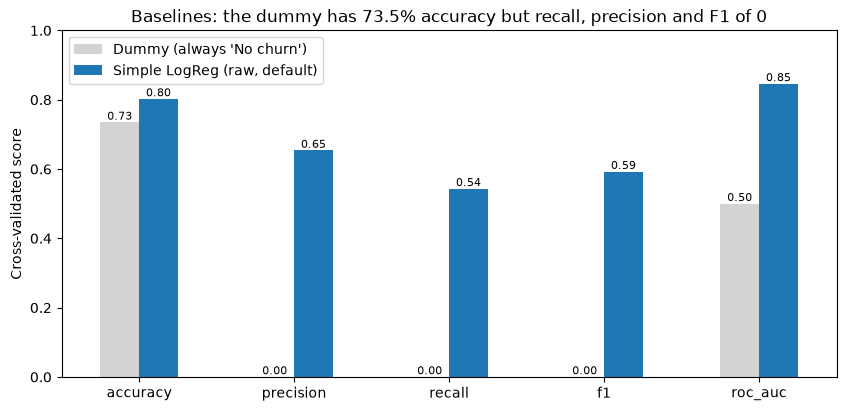

In [32]:
ax = baseline_results[["accuracy", "precision", "recall", "f1", "roc_auc"]].T.plot(  # metrics as groups, models as colours
    kind="bar", rot=0, figsize=(10, 4.5), color=["lightgray", "tab:blue"])
for container in ax.containers:                                           # write the value on every bar
    ax.bar_label(container, fmt="%.2f", fontsize=8)
ax.set_ylim(0, 1)                                                         # metrics go from 0 to 1
ax.set_ylabel("Cross-validated score")                                    # y-axis label
ax.set_title("Baselines: the dummy has 73.5% accuracy but recall, precision and F1 of 0")  # chart title
plt.show()                                                                # draw it

**What this cell does:** transposes the baseline table (`.T`) so each metric becomes a group of bars, one colour per model. The grey bars show the **accuracy paradox** visually: a tall accuracy bar next to three empty bars (precision, recall, F1 = 0) for the dummy.

---
# Step 4 — Train and compare 4 models

### 4.1 The four models

All four are from the course. They all get **class weighting**, which makes a mistake on a churner count more during training (the course's answer to imbalanced classes):
* `class_weight="balanced"` for logistic regression, Random Forest and SVM: each class is weighted inversely to its frequency (a churner weighs ≈ 2.8× a non-churner here).
* XGBoost's equivalent is `scale_pos_weight = (number of negatives) / (number of positives)`.

**What I do and why:** I define my 4 models with class weighting, because churners are the minority and missing them is the expensive mistake.

In [33]:
models = {
    "Logistic Regression": LogisticRegression(                           # linear model on a sigmoid -> probability (Session 7)
        class_weight="balanced", max_iter=1000),                         # churners weigh more; enough solver steps
    "Random Forest": RandomForestClassifier(                             # many decorrelated trees voting (Session 8)
        n_estimators=300, class_weight="balanced",                       # 300 trees; churners weigh more
        random_state=RANDOM_STATE, n_jobs=1),                            # reproducible; 1 core (CV already runs in parallel)
    "XGBoost": XGBClassifier(                                            # trees built one after another, each fixing the last (Session 9)
        n_estimators=300, learning_rate=0.05, max_depth=4,               # 300 small trees, small learning steps
        scale_pos_weight=neg / pos,                                      # XGBoost's class weighting: ~2.77
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1),     # loss to monitor; reproducible; 1 core
    "SVM": SVC(                                                          # maximum-margin boundary with an RBF kernel (Session 9)
        kernel="rbf", class_weight="balanced",                           # curved boundaries; churners weigh more
        random_state=RANDOM_STATE),                                      # reproducible
}
print("scale_pos_weight for XGBoost:", round(neg / pos, 2))              # how much more a churner weighs
print("Models:", list(models))                                           # the four names

scale_pos_weight for XGBoost: 2.77
Models: ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']


**What this cell does:** defines the four estimators in a dictionary so every later step can loop over them. `neg / pos` (computed in 2c.4 with `np.bincount`) is the ratio of non-churners to churners in the training set, ≈ 2.77. The SVM does not output probabilities; for the ranking metrics (ROC-AUC, PR-AUC) scikit-learn automatically uses its `decision_function` — the signed distance to the boundary — which ranks customers just as well. `n_jobs=1` inside the models avoids oversubscribing the CPU, because cross-validation already runs the folds in parallel.

### 4.2 Cross-validation: raw vs engineered features

Every model is cross-validated twice — on the 19 raw columns and on the 19 + 8 engineered columns — with identical folds, so the only difference is the feature engineering.

**What I do and why:** I cross-validate every model with the raw and with the engineered features, to measure whether feature engineering helps.

In [34]:
rows = []                                                                # one row per (model, feature set)
for name, model in models.items():                                       # the four models
    for engineered in [False, True]:                                     # raw features first, then engineered
        scores = cv_report(build_pipeline(clone(model), engineered=engineered))  # 5-fold CV of the whole pipeline
        rows.append({"model": name, "features": "engineered" if engineered else "raw", **scores})  # store the row
model_results = pd.DataFrame(rows).set_index(["model", "features"])      # one tidy table, indexed by model + features
model_results.round(3)                                                   # show it

accuracy  precision  recall     f1  roc_auc  \
model               features                                                  
Logistic Regression raw            0.749      0.518   0.803  0.629    0.846   
                    engineered     0.753      0.523   0.799  0.632    0.847   
Random Forest       raw            0.779      0.573   0.659  0.613    0.827   
                    engineered     0.781      0.577   0.660  0.616    0.832   
XGBoost             raw            0.757      0.529   0.774  0.628    0.842   
                    engineered     0.758      0.530   0.764  0.626    0.840   
SVM                 raw            0.751      0.521   0.783  0.625    0.828   
                    engineered     0.754      0.525   0.776  0.626    0.828   

                                pr_auc  f1_std  
model               features                    
Logistic Regression raw          0.660   0.021  
                    engineered   0.659   0.020  
Random Forest       raw          0.617   0.026  
                    engineered   0.627   0.017  
XGBoost             raw          0.662   0.013  
                    engineered   0.649   0.013  
SVM                 raw          0.602   0.021  
                    engineered   0.609   0.012

**What this cell does:** loops over the 4 models × 2 feature sets, cross-validates each complete pipeline (feature function → scaler/encoder → model, re-fitted inside every fold) and collects the mean of every metric. `**scores` unpacks the metric dictionary into the row.

**Reading the table:** with class weighting, every model now catches **about 66–80% of churners** (recall), against 54% for the simple baseline and 0% for the dummy; accuracy drops to ~0.75–0.78 — expected, because flagging more customers as churners also creates more false alarms. On F1 all four models land in a narrow band, **≈ 0.61–0.63**, and the F1 standard deviation between folds is about **0.01–0.03**, so most differences in this table are within the luck of the folds.

**What I do and why:** I compare the 4 models on several metrics in one chart.

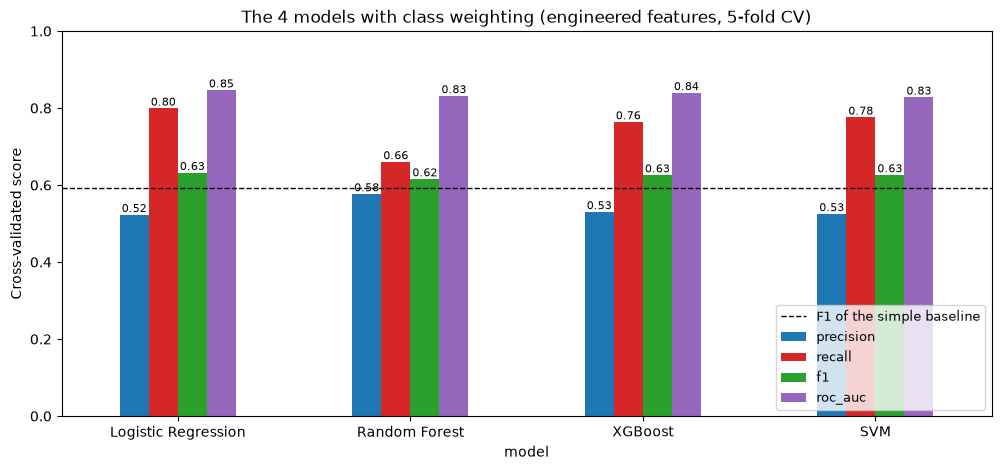

In [35]:
eng = model_results.xs("engineered", level="features")[["precision", "recall", "f1", "roc_auc"]]  # the 4 models, engineered features
ax = eng.plot(kind="bar", rot=0, figsize=(12, 5),                         # one group per model, one colour per metric
              color=["tab:blue", "tab:red", "tab:green", "tab:purple"])
for container in ax.containers:                                           # write the value on every bar
    ax.bar_label(container, fmt="%.2f", fontsize=8)
ax.axhline(baseline_results.loc["Simple LogReg (raw, default)", "f1"],    # reference: F1 of the simple baseline
           color="black", linestyle="--", lw=1, label="F1 of the simple baseline")
ax.set_ylim(0, 1)                                                         # metrics go from 0 to 1
ax.set_ylabel("Cross-validated score")                                    # y-axis label
ax.set_title("The 4 models with class weighting (engineered features, 5-fold CV)")  # chart title
ax.legend(loc="lower right", fontsize=9)                                  # legend
plt.show()                                                                # draw it

**What this cell does:** `xs("engineered", level="features")` selects the rows with engineered features from the two-level table; the chart shows four metrics per model. All four models have **similar heights**: recall (red) around 0.66–0.80 and precision (blue) around 0.52–0.58 — class weighting trades precision for recall — and every green F1 bar is above the dashed line of the simple baseline.

### 4.3 Did feature engineering help?

**What I do and why:** I calculate the exact gain from feature engineering for each model.

In [36]:
fe_gain = model_results[["f1", "roc_auc"]].unstack("features")          # raw and engineered side by side
fe_gain.columns = [f"{metric} ({feat})" for metric, feat in fe_gain.columns]  # flatten the column names
fe_gain["F1 gain"] = fe_gain["f1 (engineered)"] - fe_gain["f1 (raw)"]    # positive = feature engineering helped
fe_gain["F1 fold std"] = model_results.xs("engineered", level="features")["f1_std"]  # the size of the "luck" for comparison
fe_gain.round(3)                                                         # show the table

,f1 (engineered),f1 (raw),roc_auc (engineered),roc_auc (raw),F1 gain,F1 fold std
model,,,,,,
Logistic Regression,0.632,0.629,0.847,0.846,0.003,0.020
Random Forest,0.616,0.613,0.832,0.827,0.003,0.017
SVM,0.626,0.625,0.828,0.828,0.001,0.012
XGBoost,0.626,0.628,0.840,0.842,-0.002,0.013


**What this cell does:** `unstack("features")` moves the raw/engineered rows into columns so they sit side by side, and `F1 gain` is the difference. `F1 fold std` is the fold-to-fold spread, for scale.

**The honest answer: feature engineering changed the F1 score by less than ±0.01 for every model** — smaller than the fold-to-fold spread. This is exactly the lesson of the Session 13 slide on this same dataset: the new features **rearrange information that is already in the columns** (`avg_monthly` comes from `TotalCharges` and `tenure`, `num_services` from the service columns, `tenure_group` from `tenure`), and a model with enough flexibility can already use that information. Feature engineering helps most when it brings **new** information (data from outside these columns). We keep the engineered features in the final pipelines — they do not hurt, they make the models easier to interpret (bonus section B1 shows they rise to the top of the importance ranking), and they match the course's toolkit — but we do **not** claim they improved the score.

**What I do and why:** I show that gain with error bars, to see whether it is bigger than the normal noise between folds.

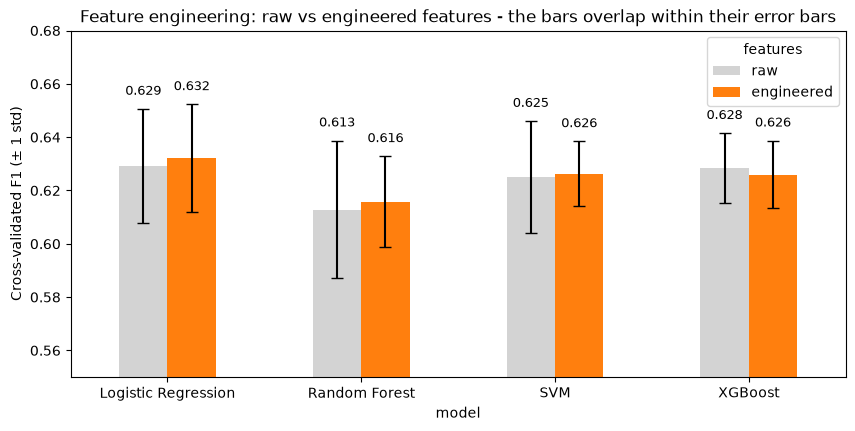

In [37]:
f1_tab = model_results["f1"].unstack("features")[["raw", "engineered"]]   # F1: one row per model, raw vs engineered
err = model_results["f1_std"].unstack("features")[["raw", "engineered"]]  # the fold-to-fold spread, as error bars
ax = f1_tab.plot(kind="bar", yerr=err, capsize=4, rot=0, figsize=(10, 4.5),  # grouped bars with error bars
                 color=["lightgray", "tab:orange"])
for container in [c for c in ax.containers if type(c).__name__ == "BarContainer"]:  # bars only, not error bars
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=8)
ax.set_ylim(0.55, 0.68)                                                   # zoom: the differences are tiny
ax.set_ylabel("Cross-validated F1 (± 1 std)")                             # y-axis label
ax.set_title("Feature engineering: raw vs engineered features - the bars overlap within their error bars")
plt.show()                                                                # draw it

**What this cell does:** `unstack` puts raw and engineered F1 side by side for each model; `yerr=err` adds an **error bar** of ± one fold standard deviation on top of each bar. The grey and orange bars are almost the same height and their error bars overlap completely — the visual proof that feature engineering did not change the score in a meaningful way.

### 4.4 Tuning, part 1 — a wide random search (course checklist 09)

The course's strategy: first a **wide `RandomizedSearchCV`** over large ranges, then a **small `GridSearchCV`** around the best values. We tune the **whole pipeline** (`model__...` addresses a parameter of the step called `model`), so the scaler and encoder are re-fitted inside every fold — no leakage. The search optimises our main metric, **F1**.

**What I do and why:** I tune each model with a wide random search (the course's strategy), optimising F1 with cross-validation.

In [38]:
search_spaces = {                                                        # where each model's hyperparameters are drawn from
    "Logistic Regression": {
        "model__C": loguniform(1e-3, 1e2),                               # inverse regularization strength: 0.001 .. 100
    },
    "Random Forest": {
        "model__n_estimators": randint(100, 600),                        # number of trees
        "model__max_depth": [4, 6, 8, 10, 12, 16, None],                 # maximum depth of each tree (None = unlimited)
        "model__min_samples_leaf": randint(1, 40),                       # minimum customers per leaf (higher = smoother)
        "model__max_features": ["sqrt", "log2", 0.5],                    # columns considered at each split
    },
    "XGBoost": {
        "model__n_estimators": randint(100, 800),                        # number of boosting rounds (trees)
        "model__learning_rate": loguniform(0.01, 0.3),                   # how big each correction step is
        "model__max_depth": randint(2, 8),                               # depth of each small tree
        "model__subsample": uniform(0.6, 0.4),                           # share of rows per tree: 0.6 .. 1.0
        "model__colsample_bytree": uniform(0.5, 0.5),                    # share of columns per tree: 0.5 .. 1.0
        "model__min_child_weight": randint(1, 20),                       # minimum weight in a leaf (higher = more cautious)
    },
    "SVM": {
        "model__C": loguniform(0.05, 50),                                # penalty for points on the wrong side of the margin
        "model__gamma": loguniform(1e-3, 1),                             # reach of each point in the RBF kernel
    },
}
n_iter = {"Logistic Regression": 20, "Random Forest": 25, "XGBoost": 25, "SVM": 15}  # random draws per model


def short(params):
    """Make best_params_ readable: drop the 'model__' prefix and round the floats."""
    return {k.replace("model__", ""): (round(float(v), 4) if isinstance(v, float) else v) for k, v in params.items()}


random_searches = {}                                                     # keep every fitted search
for name, model in models.items():                                       # tune each of the four models
    search = RandomizedSearchCV(
        build_pipeline(clone(model)),                                    # the whole pipeline is tuned
        search_spaces[name],                                             # where to draw the parameters from
        n_iter=n_iter[name],                                             # how many random combinations to try
        scoring="f1", cv=cv,                                             # main metric, same 5 stratified folds
        random_state=RANDOM_STATE, n_jobs=-1,                            # reproducible draws, all CPU cores
    )
    search.fit(X_train, y_train)                                         # n_iter x 5 fits, training set only
    random_searches[name] = search                                       # store it
    print(f"{name:20s} best CV F1 = {search.best_score_:.4f}   {short(search.best_params_)}")  # result line

Logistic Regression  best CV F1 = 0.6327   {'C': 0.4205}
Random Forest        best CV F1 = 0.6347   {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 33, 'n_estimators': 559}
XGBoost              best CV F1 = 0.6316   {'colsample_bytree': 0.5853, 'learning_rate': 0.0125, 'max_depth': 5, 'min_child_weight': 14, 'n_estimators': 341, 'subsample': 0.7542}
SVM                  best CV F1 = 0.6251   {'C': 0.409, 'gamma': 0.0375}


**What this cell does:** `search_spaces` gives each model a **distribution** to draw from: `loguniform(a, b)` spreads draws evenly across orders of magnitude (good for `C`, `learning_rate`, `gamma`), `randint(a, b)` draws integers, `uniform(loc, width)` draws floats between `loc` and `loc + width`, and a list is sampled uniformly. `RandomizedSearchCV` tries `n_iter` random combinations, each with 5-fold CV, and keeps the best by F1; at the end it **refits the best pipeline on the whole training set** (`best_estimator_`). `short()` just makes the printout readable.

**Result:** tuning moves each model by only about **0.00–0.02 F1**, and the four best scores are within about **0.01** of each other. The tuned Random Forest prefers shallow, smooth trees (`max_depth` 10, `min_samples_leaf` 33): it regularises the forest that was overfitting with unlimited depth. Logistic regression prefers `C` ≈ 0.4 (slightly more regularization than the default 1.0).

**What did the random search explore?** Each dot below is one combination tried by `RandomizedSearchCV`; the star is the best one.

**What I do and why:** I plot every combination the random search tried, to see how each parameter affects the score.

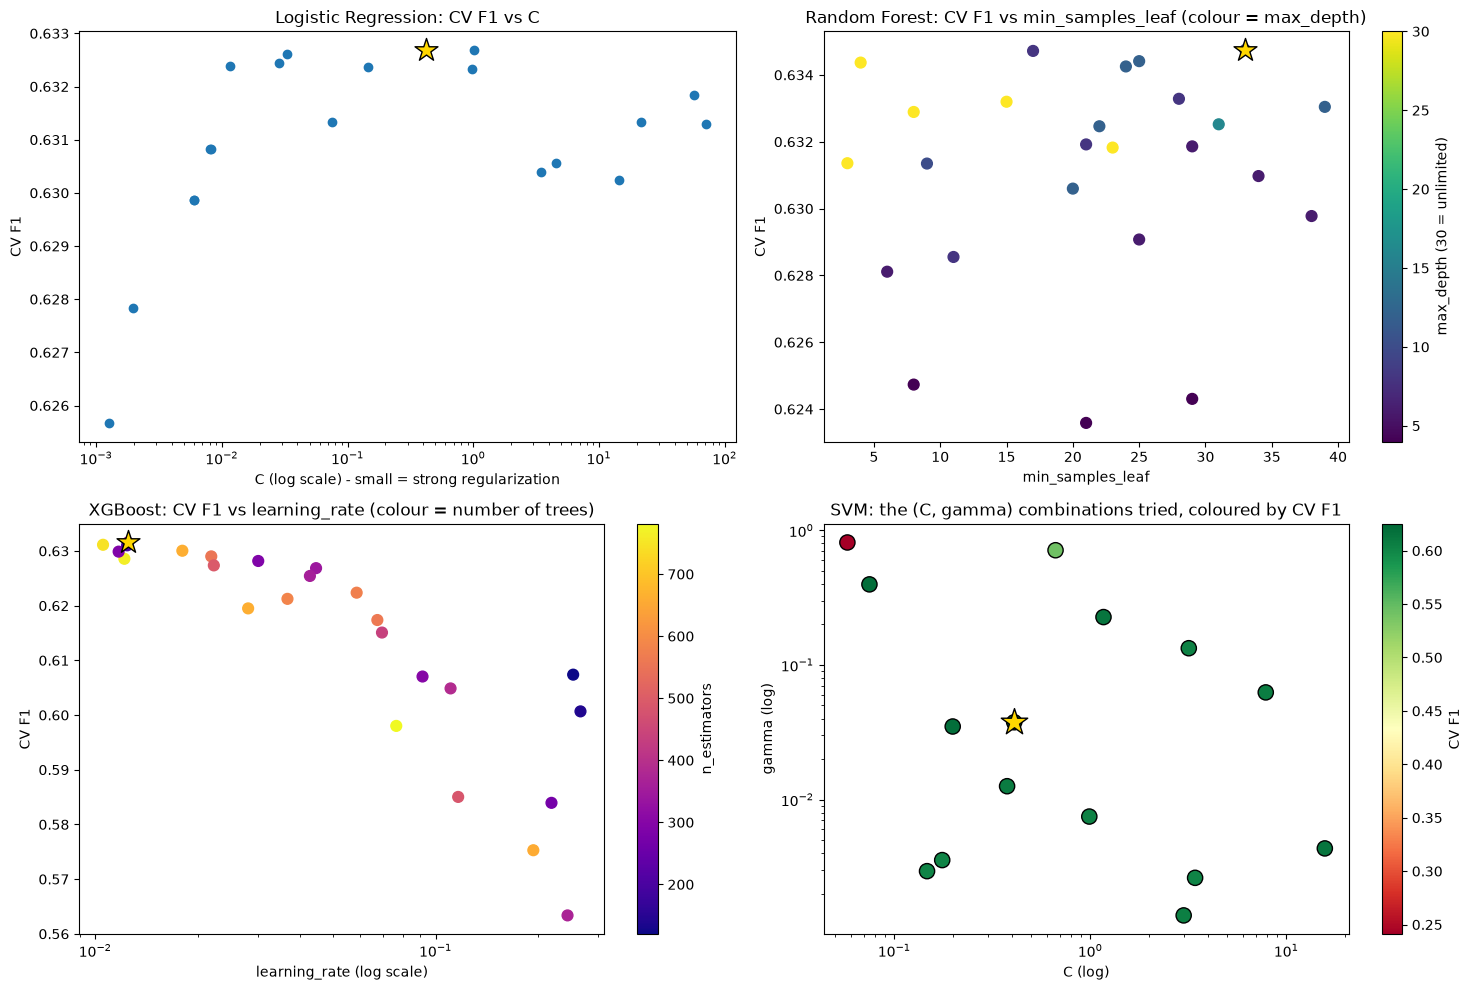

In [39]:
def search_results(name):
    """The random search's results as a DataFrame (one row per combination tried)."""
    return pd.DataFrame(random_searches[name].cv_results_)               # params + mean CV F1 of every try


fig, axes = plt.subplots(2, 2, figsize=(15, 10))                          # one panel per model

r = search_results("Logistic Regression")                                 # LR: only C was tuned
x = r["param_model__C"].astype(float)                                     # the C value of each try
axes[0, 0].scatter(x, r["mean_test_score"], c="tab:blue")                 # one dot per try
best = r["rank_test_score"].idxmin()                                      # row of the best try
axes[0, 0].scatter(x[best], r.loc[best, "mean_test_score"], marker="*", s=300, c="gold", edgecolors="black")  # the winner
axes[0, 0].set_xscale("log")                                              # C spans 5 orders of magnitude
axes[0, 0].set_title("Logistic Regression: CV F1 vs C")                   # panel title
axes[0, 0].set_xlabel("C (log scale) - small = strong regularization")    # x-axis label

r = search_results("Random Forest")                                       # RF: 4 parameters were tuned
depth = pd.to_numeric(r["param_model__max_depth"], errors="coerce").fillna(30)  # None (unlimited) shown as 30
sc = axes[0, 1].scatter(r["param_model__min_samples_leaf"].astype(float), r["mean_test_score"],  # x = leaf size
                        c=depth, cmap="viridis", s=60)                    # colour = max_depth
best = r["rank_test_score"].idxmin()                                      # the winner
axes[0, 1].scatter(float(r.loc[best, "param_model__min_samples_leaf"]), r.loc[best, "mean_test_score"],
                   marker="*", s=300, c="gold", edgecolors="black")
plt.colorbar(sc, ax=axes[0, 1], label="max_depth (30 = unlimited)")       # colour legend
axes[0, 1].set_title("Random Forest: CV F1 vs min_samples_leaf (colour = max_depth)")  # panel title
axes[0, 1].set_xlabel("min_samples_leaf")                                 # x-axis label

r = search_results("XGBoost")                                             # XGBoost: 6 parameters were tuned
sc = axes[1, 0].scatter(r["param_model__learning_rate"].astype(float), r["mean_test_score"],  # x = learning rate
                        c=r["param_model__n_estimators"].astype(float), cmap="plasma", s=60)  # colour = trees
best = r["rank_test_score"].idxmin()                                      # the winner
axes[1, 0].scatter(float(r.loc[best, "param_model__learning_rate"]), r.loc[best, "mean_test_score"],
                   marker="*", s=300, c="gold", edgecolors="black")
plt.colorbar(sc, ax=axes[1, 0], label="n_estimators")                     # colour legend
axes[1, 0].set_xscale("log")                                              # learning rate spans 1.5 orders of magnitude
axes[1, 0].set_title("XGBoost: CV F1 vs learning_rate (colour = number of trees)")  # panel title
axes[1, 0].set_xlabel("learning_rate (log scale)")                        # x-axis label

r = search_results("SVM")                                                 # SVM: C and gamma were tuned
sc = axes[1, 1].scatter(r["param_model__C"].astype(float), r["param_model__gamma"].astype(float),  # x = C, y = gamma
                        c=r["mean_test_score"], cmap="RdYlGn", s=120, edgecolors="black")  # colour = CV F1
best = r["rank_test_score"].idxmin()                                      # the winner
axes[1, 1].scatter(float(r.loc[best, "param_model__C"]), float(r.loc[best, "param_model__gamma"]),
                   marker="*", s=400, c="gold", edgecolors="black")
plt.colorbar(sc, ax=axes[1, 1], label="CV F1")                            # colour legend
axes[1, 1].set_xscale("log"); axes[1, 1].set_yscale("log")                # both span orders of magnitude
axes[1, 1].set_title("SVM: the (C, gamma) combinations tried, coloured by CV F1")  # panel title
axes[1, 1].set_xlabel("C (log)"); axes[1, 1].set_ylabel("gamma (log)")    # axis labels

for ax in axes.ravel()[:3]:                                               # the three "score vs parameter" panels
    ax.set_ylabel("CV F1")                                                # share the same y label
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

**What this cell does:** `cv_results_` stores every combination the random search tried with its mean CV score; `rank_test_score == 1` (found with `idxmin`) is the winner, drawn as a gold star. Log scales are used for parameters drawn with `loguniform`.

**What we see:**
* **Logistic regression:** F1 is flat for most values of `C` and only drops when `C` is very small (very strong regularization squeezes the coefficients towards 0).
* **Random Forest:** the **very shallow trees** (`max_depth` 4, darkest dots) are the worst — too simple to capture the patterns. All the other combinations land within about 0.005 of each other: once the trees are deep enough, the forest is not very sensitive to its settings (averaging many trees protects it).
* **XGBoost:** a clear trend — the **higher the learning rate, the lower the F1** (from ~0.63 at 0.01 down to ~0.56 at 0.25). Each new tree corrects the previous ones too aggressively and the model overfits; small steps with many trees work best.
* **SVM:** almost every combination is good (dark green); the poor ones are at a **large gamma** (top of the panel), especially with a small `C` — there each customer only influences its immediate neighbours and the model breaks down.

### 4.5 Tuning, part 2 — a fine grid around the best Random Forest

The Random Forest had the best random-search score, so we refine it with a small `GridSearchCV` around its best values (the course's "fine grid" step). The grid is built from the random search's own result.

**What I do and why:** I refine the best model (Random Forest) with a small grid around its best values.

In [40]:
best_rf = random_searches["Random Forest"].best_params_                  # the winner of the wide search
d, leaf = best_rf["model__max_depth"], best_rf["model__min_samples_leaf"]  # its depth and leaf size
fine_grid = {
    "model__max_depth": [d - 2, d, d + 2],                               # a little shallower / same / deeper
    "model__min_samples_leaf": [max(1, leaf - 10), leaf, leaf + 10],     # a little smaller / same / bigger leaves
    "model__max_features": ["sqrt", 0.3],                                # the winner's choice and one neighbour
    "model__n_estimators": [best_rf["model__n_estimators"]],             # number of trees barely matters: keep it
}
grid_rf = GridSearchCV(build_pipeline(clone(models["Random Forest"])),   # same pipeline as before
                       fine_grid, scoring="f1", cv=cv, n_jobs=-1)        # every combination, 5 folds, F1
grid_rf.fit(X_train, y_train)                                            # 3 x 3 x 2 = 18 combinations x 5 folds
print("Random search best F1:", round(random_searches["Random Forest"].best_score_, 4))  # before the fine grid
print("Fine grid best F1:    ", round(grid_rf.best_score_, 4), short(grid_rf.best_params_))  # after the fine grid

Random search best F1: 0.6347
Fine grid best F1:     0.6347 {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 33, 'n_estimators': 559}


**What this cell does:** reads the best `max_depth` and `min_samples_leaf` from the random search and builds a **3 × 3 × 2 grid** around them; `GridSearchCV` tries all 18 combinations with the same 5 folds. The fine grid can only confirm or slightly improve the random search, since the random search's best point is inside the grid. **Result:** the fine grid **confirms** the random search's best point (same parameters, same F1 of 0.635) — none of the neighbours does better. The random search had already found the good zone, which is exactly what the course predicts: *tuning usually brings a few percent at most; better data brings more.*

### 4.5b What happens if we increase or decrease a hyperparameter? (validation curves)

A **validation curve** changes **one** hyperparameter of a tuned pipeline (everything else stays fixed) and plots the **training** F1 and the **cross-validated** F1 for each value:
* both curves low → **underfitting** (the model is too simple);
* training high but validation clearly lower → **overfitting** (the model memorises the training customers);
* the best value is where the **validation** curve peaks.

**What I do and why:** I change one parameter at a time to see when each model underfits or overfits.

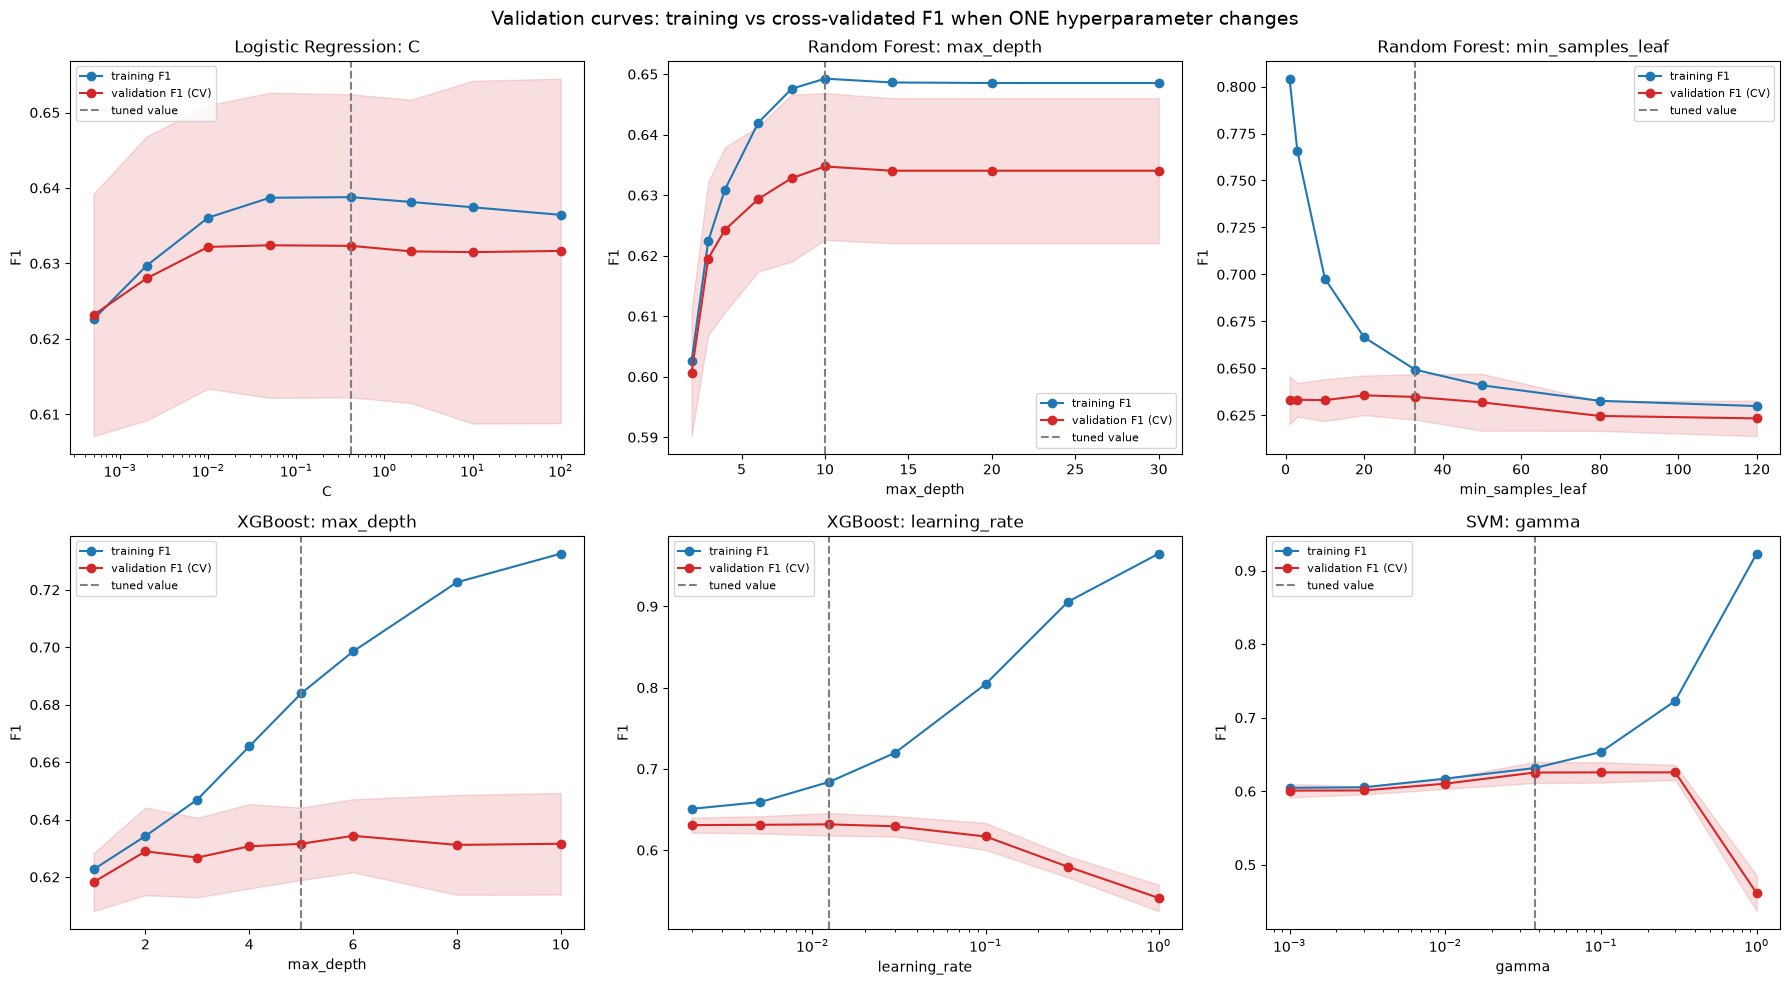

train F1  validation F1    gap
model               parameter        value                                   
Logistic Regression C                0.0005       0.623          0.623 -0.001
                                     0.0020       0.630          0.628  0.002
                                     0.0100       0.636          0.632  0.004
                                     0.0500       0.639          0.632  0.006
                                     0.4200       0.639          0.632  0.006
                                     2.0000       0.638          0.632  0.007
                                     10.0000      0.637          0.631  0.006
                                     100.0000     0.636          0.632  0.005
Random Forest       max_depth        2.0000       0.603          0.601  0.002
                                     3.0000       0.622          0.620  0.003
                                     4.0000       0.631          0.624  0.007
                                     6.0000       0.642          0.629  0.013
                                     8.0000       0.648          0.633  0.015
                                     10.0000      0.649          0.635  0.015
                                     14.0000      0.649          0.634  0.015
                                     20.0000      0.649          0.634  0.014
                                     30.0000      0.649          0.634  0.014
                    min_samples_leaf 1.0000       0.804          0.633  0.171
                                     3.0000       0.766          0.633  0.132
                                     10.0000      0.698          0.633  0.065
                                     20.0000      0.667          0.636  0.031
                                     33.0000      0.649          0.635  0.015
                                     50.0000      0.641          0.632  0.009
                                     80.0000      0.633          0.625  0.008
                                     120.0000     0.630          0.623  0.007
XGBoost             max_depth        1.0000       0.623          0.618  0.004
                                     2.0000       0.634          0.629  0.005
                                     3.0000       0.647          0.627  0.020
                                     4.0000       0.665          0.631  0.035
                                     5.0000       0.684          0.632  0.052
                                     6.0000       0.699          0.634  0.064
                                     8.0000       0.723          0.631  0.091
                                     10.0000      0.733          0.632  0.101
                    learning_rate    0.0020       0.651          0.631  0.020
                                     0.0050       0.659          0.631  0.028
                                     0.0125       0.684          0.632  0.052
                                     0.0300       0.720          0.629  0.090
                                     0.1000       0.804          0.617  0.188
                                     0.3000       0.906          0.579  0.326
                                     1.0000       0.965          0.541  0.424
SVM                 gamma            0.0010       0.605          0.601  0.004
                                     0.0030       0.605          0.601  0.004
                                     0.0100       0.617          0.610  0.007
                                     0.0375       0.632          0.625  0.006
                                     0.1000       0.653          0.626  0.028
                                     0.3000       0.723          0.626  0.097
                                     1.0000       0.923          0.461  0.461

In [41]:
curve_specs = [                                                           # (model, tuned pipeline, parameter, values to try, log x-axis?)
    ("Logistic Regression", random_searches["Logistic Regression"].best_estimator_, "model__C",
     [0.0005, 0.002, 0.01, 0.05, 0.42, 2, 10, 100], True),
    ("Random Forest", grid_rf.best_estimator_, "model__max_depth", [2, 3, 4, 6, 8, 10, 14, 20, 30], False),
    ("Random Forest", grid_rf.best_estimator_, "model__min_samples_leaf", [1, 3, 10, 20, 33, 50, 80, 120], False),
    ("XGBoost", random_searches["XGBoost"].best_estimator_, "model__max_depth", [1, 2, 3, 4, 5, 6, 8, 10], False),
    ("XGBoost", random_searches["XGBoost"].best_estimator_, "model__learning_rate",
     [0.002, 0.005, 0.0125, 0.03, 0.1, 0.3, 1.0], True),
    ("SVM", random_searches["SVM"].best_estimator_, "model__gamma", [0.001, 0.003, 0.01, 0.0375, 0.1, 0.3, 1.0], True),
]
curve_rows = []                                                           # numbers behind the curves, printed below
fig, axes = plt.subplots(2, 3, figsize=(18, 10))                          # one panel per (model, parameter)
for ax, (name, pipe, param, values, log_x) in zip(axes.ravel(), curve_specs):  # loop over the six experiments
    train_sc, val_sc = validation_curve(clone(pipe), X_train, y_train,    # refit for every value, 5 folds each
                                        param_name=param, param_range=values,
                                        cv=cv, scoring="f1", n_jobs=-1)
    tr_mean, va_mean, va_std = train_sc.mean(axis=1), val_sc.mean(axis=1), val_sc.std(axis=1)  # average over folds
    ax.plot(values, tr_mean, "o-", color="tab:blue", label="training F1")  # how well it fits what it saw
    ax.plot(values, va_mean, "o-", color="tab:red", label="validation F1 (CV)")  # how well it generalises
    ax.fill_between(values, va_mean - va_std, va_mean + va_std, color="tab:red", alpha=0.15)  # ± 1 std band
    ax.axvline(pipe.get_params()[param], color="gray", linestyle="--", label="tuned value")  # what we chose
    if log_x:                                                             # parameters spanning orders of magnitude
        ax.set_xscale("log")
    short_name = param.replace("model__", "")                             # e.g. "max_depth"
    ax.set_title(f"{name}: {short_name}")                                 # panel title
    ax.set_xlabel(short_name)                                             # x-axis label
    ax.set_ylabel("F1")                                                   # y-axis label
    ax.legend(fontsize=8)                                                 # legend
    for v, t, s in zip(values, tr_mean, va_mean):                         # keep the numbers
        curve_rows.append({"model": name, "parameter": short_name, "value": v,
                           "train F1": round(t, 3), "validation F1": round(s, 3), "gap": round(t - s, 3)})
plt.suptitle("Validation curves: training vs cross-validated F1 when ONE hyperparameter changes", fontsize=14)
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

curves = pd.DataFrame(curve_rows).set_index(["model", "parameter", "value"])  # all numbers in one table
curves                                                                    # show the table

**What this cell does:** `validation_curve` takes a tuned pipeline, sets **one** parameter to each value in the list, and runs 5-fold CV for each, returning the training and validation scores of every fold. Blue = training F1, red = validation F1 with a ± 1 std band, dashed = the value we tuned. The table underneath has the exact numbers (`gap` = training − validation: a big gap means overfitting).

**How to read each panel:**
* **Logistic Regression — `C`** (inverse of regularization): very small `C` forces the coefficients towards 0 → both curves drop (underfitting: 0.623 at `C` = 0.0005). From about `C` = 0.01 upwards the curves are flat (≈ 0.632) and the training and validation curves stay within 0.01 of each other: the model is so simple that it cannot overfit 5,600 customers, so extra freedom changes nothing.
* **Random Forest — `max_depth`:** shallow trees (2–3) underfit; as depth grows the **training** F1 keeps climbing while the **validation** F1 levels off — the widening gap is overfitting starting. Our `min_samples_leaf = 33` keeps the gap small even for deep trees.
* **Random Forest — `min_samples_leaf`:** with 1 customer per leaf the trees memorise the training data (**training F1 0.80**), yet the **validation F1 barely moves** (0.633 vs 0.635 at 33) — averaging hundreds of different trees cancels most of their individual overfitting. Larger leaves close the gap (an honest, simpler model with the same validation score); too large (≥ 80) and the trees become too coarse and the validation F1 starts to fall.
* **XGBoost — `max_depth`:** depth 1 (stumps) underfits; deeper trees push the training F1 up much faster than the validation F1 → overfitting with deep boosted trees.
* **XGBoost — `learning_rate`** (with the number of trees fixed at 341): small rates all give about the same validation F1 (≈ 0.63) — the few strong effects are learned quickly; as the rate grows each tree over-corrects → the **training F1 shoots up to 0.97 while the validation F1 falls to 0.54** at a rate of 1.0: the clearest overfitting picture in the notebook.
* **SVM — `gamma`:** small gamma = smooth, wide boundary (slight underfitting, ≈ 0.60); large gamma = each customer influences only its close neighbours → the boundary wraps around individual customers: at gamma = 1 the **training F1 is 0.92 and the validation F1 collapses to 0.46** (overfitting).

### 4.6 The tuned models, side by side (cross-validation, training set only)

**What I do and why:** I compare the 4 tuned models and the baselines on exactly the same folds.

In [42]:
tuned = {                                                                # the best pipeline of each model
    "Logistic Regression": random_searches["Logistic Regression"].best_estimator_,
    "Random Forest": grid_rf.best_estimator_,                            # the fine-grid version
    "XGBoost": random_searches["XGBoost"].best_estimator_,
    "SVM": random_searches["SVM"].best_estimator_,
}
tuned_results = pd.DataFrame({name: cv_report(clone(pipe)) for name, pipe in tuned.items()}).T  # full CV metrics
tuned_results = pd.concat([baseline_results, tuned_results])             # add the two baselines on top
tuned_results.round(3)                                                   # show the comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_std
Dummy (always 'No churn'),0.735,0.000,0.000,0.000,0.500,0.265,0.000
"Simple LogReg (raw, default)",0.802,0.654,0.543,0.593,0.846,0.661,0.030
Logistic Regression,0.754,0.523,0.800,0.633,0.847,0.658,0.020
Random Forest,0.754,0.524,0.805,0.635,0.847,0.660,0.012
XGBoost,0.755,0.526,0.790,0.632,0.846,0.660,0.013
SVM,0.746,0.513,0.799,0.625,0.836,0.638,0.015


**What this cell does:** collects the best pipeline of each model (`best_estimator_`), cross-validates a fresh copy of each (`clone`) to get **all** metrics with the same folds, and stacks the two baselines on top for comparison.

**Which model came out best, and why?** All four tuned models reach **F1 ≈ 0.63** and **ROC-AUC ≈ 0.84–0.85**; the gaps between them (≤ 0.01) are **no bigger than the fold-to-fold spread (≈ 0.01–0.02)**, so in cross-validation they are statistically tied. Our reading: the churn signal in Telco is **mostly simple and close to linear** — a few strong, one-directional effects (month-to-month contract, short tenure, fiber-optic internet, electronic-check payment, paperless billing — see bonus B3) that add up. A linear model captures that almost perfectly, so the flexible models (forest, boosting, SVM) have little extra structure to find, and the ensembles' main advantage — complex interactions — has little to work with. All four beat the dummy by a mile and the simple baseline by **≈ +0.04 F1** and **≈ +0.25 recall**, mostly thanks to class weighting.

**What I do and why:** I plot the F1 of every fold, to see whether the differences between models are real or just noise.

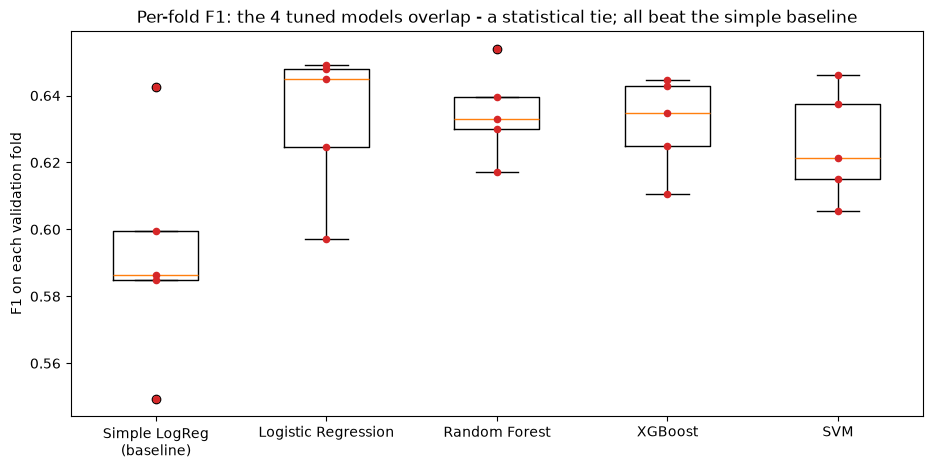

In [43]:
contenders = {"Simple LogReg\n(baseline)": baselines["Simple LogReg (raw, default)"], **tuned}  # baseline + 4 tuned models
fold_f1 = {name: cross_val_score(clone(pipe), X_train, y_train, cv=cv,    # F1 on each of the 5 folds
                                 scoring="f1", n_jobs=-1)
           for name, pipe in contenders.items()}
fig, ax = plt.subplots(figsize=(11, 5))                                   # one chart
ax.boxplot(list(fold_f1.values()), tick_labels=list(fold_f1.keys()))      # one box per model: spread over the folds
for i, scores in enumerate(fold_f1.values(), start=1):                    # also draw the 5 individual fold scores
    ax.scatter([i] * len(scores), scores, color="tab:red", zorder=3, s=20)
ax.set_ylabel("F1 on each validation fold")                               # y-axis label
ax.set_title("Per-fold F1: the 4 tuned models overlap - a statistical tie; all beat the simple baseline")  # title
plt.show()                                                                # draw it

**What this cell does:** `cross_val_score` returns the 5 individual fold scores (instead of only their mean); `ax.boxplot` draws one box per model and the red dots are the 5 folds. The boxes of the four tuned models **overlap almost completely** — which is what "statistically tied" means visually — while the simple baseline's box sits lower. This picture is the honest answer to "which model is best?": *on this data, several of them are equally good.*

### 4.7 Choosing the final model

Rule used (decided *before* looking at the test set): take the model with the **highest cross-validated F1**. When the differences are within the noise, the course's advice (Session 11) is to prefer the **simpler** model — we come back to that in the conclusion.

**What I do and why:** I choose the final model with the rule I fixed before looking at the test set: the best cross-validated F1.

In [44]:
model_rows = tuned_results.drop(index=list(baselines))                   # only the 4 tuned models (not the baselines)
final_name = model_rows["f1"].idxmax()                                   # the name with the best mean CV F1
final_model = tuned[final_name]                                          # its pipeline (already refitted on all of train)
print("Final model:", final_name)                                        # which one
print("CV F1 = %.3f +/- %.3f" % (model_rows.loc[final_name, "f1"], model_rows.loc[final_name, "f1_std"]))  # its score
print("Gap to the 2nd best model: %.3f" % (model_rows["f1"].nlargest(2).diff().abs().iloc[1]))  # how close the race is

Final model: Random Forest
CV F1 = 0.635 +/- 0.012
Gap to the 2nd best model: 0.002


**What this cell does:** drops the two baselines, then `idxmax()` returns the model name with the highest mean CV F1. `nlargest(2).diff()` computes the gap between the best and the second-best model, which we compare with the F1 standard deviation printed next to it.

### 4.8 Choosing the decision threshold (out-of-fold, training set only)

By default a classifier says "churn" when its probability is ≥ 0.5. That threshold is arbitrary; we can choose the one that maximises F1. To do it honestly we need probabilities for training customers **from models that never saw them**: `cross_val_predict` gives exactly that (out-of-fold predictions). The test set is still untouched.

**What I do and why:** I choose the decision threshold with out-of-fold predictions on the training set, so the test set stays untouched.

F1 at threshold 0.50: 0.635
Best threshold: 0.53 -> F1 = 0.637


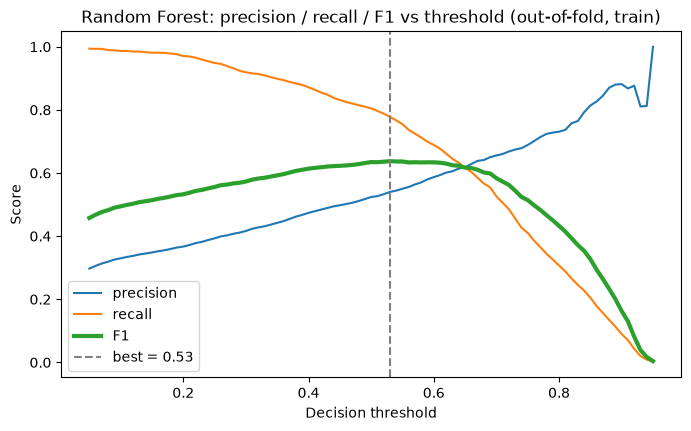

In [45]:
oof_proba = cross_val_predict(clone(final_model), X_train, y_train, cv=cv,  # 5 models, each predicts its unseen fold
                              method="predict_proba", n_jobs=-1)[:, 1]   # probability of class 1 (churn)
thresholds = np.arange(0.05, 0.96, 0.01)                                  # candidate thresholds 0.05 .. 0.95
f1s = [f1_score(y_train, oof_proba >= t) for t in thresholds]            # F1 at every threshold
precisions = [precision_score(y_train, oof_proba >= t, zero_division=0) for t in thresholds]  # precision at every threshold
recalls = [recall_score(y_train, oof_proba >= t) for t in thresholds]    # recall at every threshold
best_threshold = float(thresholds[int(np.argmax(f1s))])                   # the threshold with the highest F1

print(f"F1 at threshold 0.50: {f1_score(y_train, oof_proba >= 0.5):.3f}")  # the default
print(f"Best threshold: {best_threshold:.2f} -> F1 = {max(f1s):.3f}")     # the tuned one

plt.plot(thresholds, precisions, label="precision")                       # precision rises with the threshold
plt.plot(thresholds, recalls, label="recall")                             # recall falls with the threshold
plt.plot(thresholds, f1s, label="F1", linewidth=3)                        # F1 peaks in between
plt.axvline(best_threshold, color="gray", linestyle="--", label=f"best = {best_threshold:.2f}")  # chosen threshold
plt.title(f"{final_name}: precision / recall / F1 vs threshold (out-of-fold, train)")  # chart title
plt.xlabel("Decision threshold"); plt.ylabel("Score")                     # axis labels
plt.legend(); plt.show()                                                  # legend + draw

**What this cell does:** `cross_val_predict(..., method="predict_proba")` trains 5 copies of the final pipeline and returns, for every training customer, the churn probability predicted by the copy that **did not** train on that customer; `[:, 1]` keeps the probability of class 1. For each threshold from 0.05 to 0.95 we compute F1, precision and recall, and `np.argmax` picks the threshold with the highest F1.

The plot shows the trade-off: a **low threshold** flags many customers → high recall, low precision; a **high threshold** flags few → high precision, low recall; F1 peaks in between. Because class weighting already shifted the model towards churners, the best threshold stays close to 0.5 and the gain is small — but it is chosen honestly, without the test set.

**What I do and why:** I show how the predicted probabilities of churners and non-churners overlap, and where my threshold cuts them.

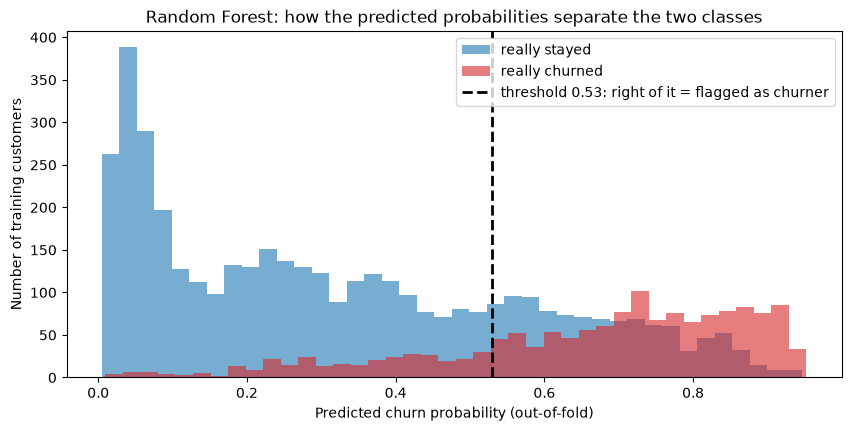

In [46]:
fig, ax = plt.subplots(figsize=(10, 4.5))                                 # one chart
ax.hist(oof_proba[y_train.values == 0], bins=40, alpha=0.6, color="tab:blue", label="really stayed")  # non-churners
ax.hist(oof_proba[y_train.values == 1], bins=40, alpha=0.6, color="tab:red", label="really churned")  # churners
ax.axvline(best_threshold, color="black", linestyle="--", lw=2,           # the chosen threshold
           label=f"threshold {best_threshold:.2f}: right of it = flagged as churner")
ax.set_xlabel("Predicted churn probability (out-of-fold)")                # x-axis label
ax.set_ylabel("Number of training customers")                             # y-axis label
ax.set_title(f"{final_name}: how the predicted probabilities separate the two classes")  # chart title
ax.legend()                                                               # legend
plt.show()                                                                # draw it

**What this cell does:** draws the out-of-fold churn probabilities of the final model, separately for customers who really stayed (blue) and who really churned (red), with the threshold as a dashed line. Everything to the right of the line is flagged as a churner: red bars on the right are **caught churners**, blue bars on the right are **false alarms**, red bars on the left are **missed churners**. The two humps overlap in the middle — no threshold can separate them perfectly, which is why precision and recall have to be traded against each other. Moving the line left catches more churners (more red on the right) but adds false alarms (more blue on the right).

---
# Step 5 — Evaluate on the test set (used once)

Everything is now decided: features, model, hyperparameters, threshold. We score every model **once** on the 1,409 test customers and do not go back to tuning afterwards (that would turn the test set into a second validation set).

**What I do and why:** Now, and only once, I evaluate every model on the test set.

In [47]:
def churn_scores(pipe, X):
    """A churn score per customer: the probability if the model has one, else the SVM's decision function."""
    if hasattr(pipe, "predict_proba"):                                    # Dummy, LogReg, Random Forest, XGBoost
        return pipe.predict_proba(X)[:, 1]                                # probability of class 1 (churn)
    return pipe.decision_function(X)                                      # SVM: signed distance to the boundary


def test_report(pipe, threshold=None):
    """Score a fitted pipeline on the test set (model's own predict(), or a custom probability threshold)."""
    proba = churn_scores(pipe, X_test)                                    # churn score for every test customer
    if threshold is None:                                                 # default: the model's own decision rule
        pred = pipe.predict(X_test)                                       # labels exactly as the model predicts them
    else:                                                                 # custom threshold on the probability
        pred = (proba >= threshold).astype(int)                           # 1 = predicted churner
    return {"accuracy": accuracy_score(y_test, pred),                     # share of correct answers
            "precision": precision_score(y_test, pred, zero_division=0),  # of flagged customers, share that churned
            "recall": recall_score(y_test, pred),                         # of churners, share we flagged
            "f1": f1_score(y_test, pred),                                 # main metric
            "roc_auc": roc_auc_score(y_test, proba),                      # ranking quality (threshold-free)
            "pr_auc": average_precision_score(y_test, proba)}             # precision-recall area (threshold-free)


for pipe in baselines.values():                                           # the baselines were only cross-validated so far
    pipe.fit(X_train, y_train)                                            # fit them on the whole training set

test_rows = {name: test_report(pipe) for name, pipe in {**baselines, **tuned}.items()}  # every model, default decision rule
test_rows[f"{final_name} (threshold {best_threshold:.2f})"] = test_report(final_model, best_threshold)  # final model, tuned threshold
test_results = pd.DataFrame(test_rows).T                                  # one row per model
test_results.round(3)                                                     # show the table

,accuracy,precision,recall,f1,roc_auc,pr_auc
Dummy (always 'No churn'),0.735,0.000,0.000,0.000,0.500,0.265
"Simple LogReg (raw, default)",0.804,0.654,0.556,0.601,0.842,0.636
Logistic Regression,0.742,0.509,0.799,0.622,0.846,0.654
Random Forest,0.754,0.524,0.802,0.634,0.845,0.656
XGBoost,0.753,0.523,0.802,0.633,0.847,0.663
SVM,0.743,0.511,0.778,0.617,0.836,0.635
Random Forest (threshold 0.53),0.762,0.536,0.781,0.635,0.845,0.656


**What this cell does:** `churn_scores` returns a churn score per customer — the probability for the models that have one, the decision function for the SVM — used for the threshold-free ROC-AUC and PR-AUC. `test_report` gets the labels either from the model's own `predict()` or, when a threshold is given, by comparing the probability with it, then computes all six metrics against the true `y_test`. The baselines are fitted on the full training set first (the tuned models already were, by the searches). The last row is the **final model with its tuned threshold** — the configuration we recommend.

**What I do and why:** I compare the test scores with the cross-validation scores, to check that my CV estimates were honest.

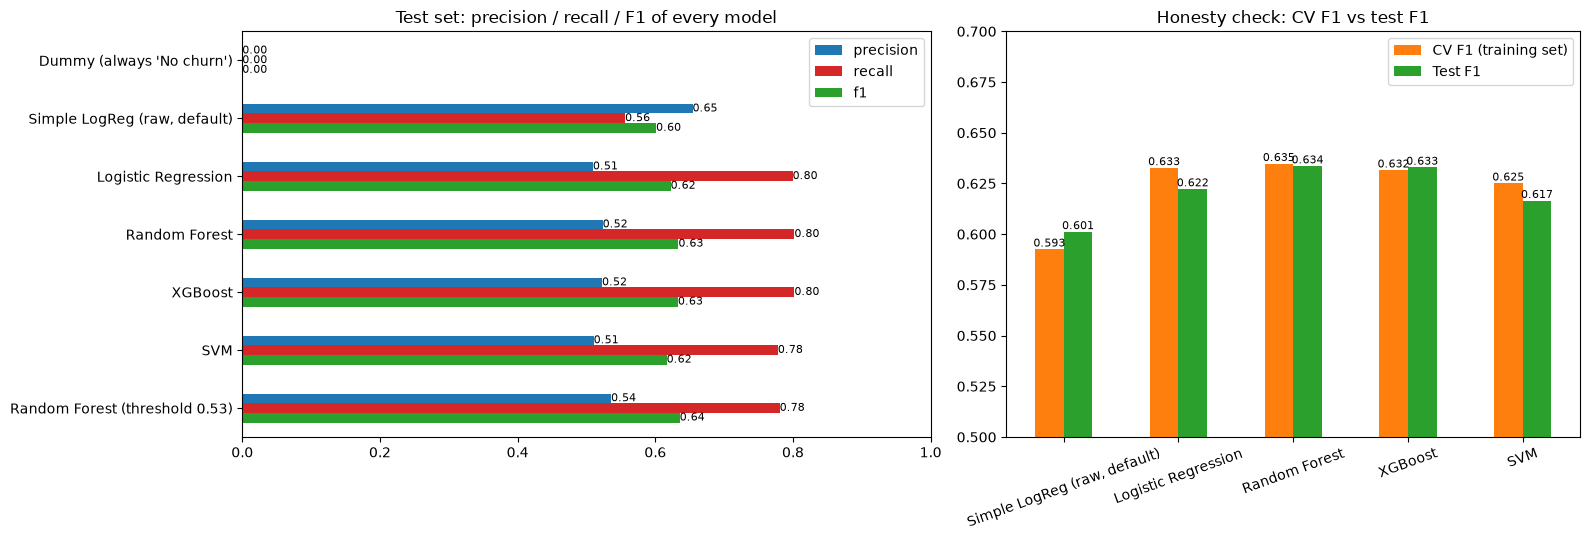

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.2, 1]})  # two charts
test_results[["precision", "recall", "f1"]].plot(kind="barh", ax=axes[0],  # one group of bars per model
                                                 color=["tab:blue", "tab:red", "tab:green"])
for container in axes[0].containers:                                      # write the values
    axes[0].bar_label(container, fmt="%.2f", fontsize=8)
axes[0].set_xlim(0, 1)                                                    # metrics go from 0 to 1
axes[0].set_title("Test set: precision / recall / F1 of every model")     # chart title
axes[0].invert_yaxis()                                                    # first model on top

cv_vs_test = pd.DataFrame({"CV F1 (training set)": tuned_results["f1"],   # what cross-validation predicted...
                           "Test F1": test_results["f1"].reindex(tuned_results.index)})  # ...and what the test says
cv_vs_test.drop(index="Dummy (always 'No churn')").plot(kind="bar", ax=axes[1], rot=20,  # the dummy is 0 everywhere
                                                         color=["tab:orange", "tab:green"])
for container in axes[1].containers:                                      # write the values
    axes[1].bar_label(container, fmt="%.3f", fontsize=8)
axes[1].set_ylim(0.5, 0.7)                                                # zoom
axes[1].set_title("Honesty check: CV F1 vs test F1")                      # chart title
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

**What this cell does:** left: the test precision (blue), recall (red) and F1 (green) of every model, as horizontal bars. Right: the **honesty check** — for each model, the F1 that cross-validation predicted on the training set (orange) next to the F1 actually measured on the test set (green). The bars are close for every model, so the cross-validation estimates were trustworthy: no model was overfitted to the training data or to the tuning.

### 5.2 Confusion matrices

**What I do and why:** I draw the confusion matrices to count the caught churners, the missed churners and the false alarms.

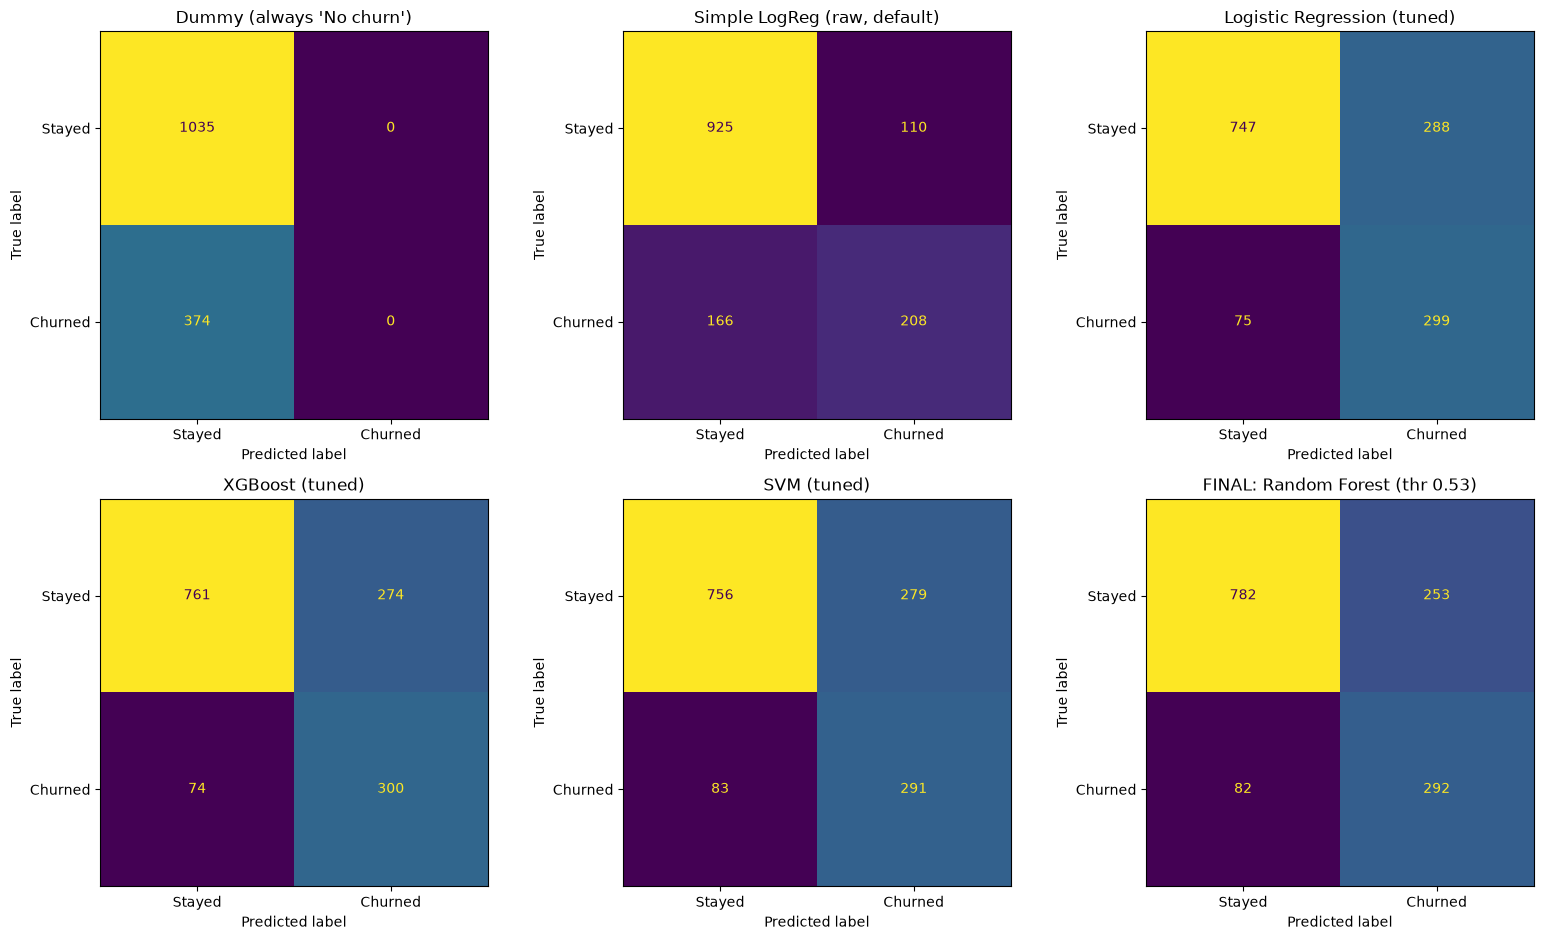

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))                         # six matrices in a 2 x 3 grid
to_show = [("Dummy (always 'No churn')", baselines["Dummy (always 'No churn')"], None),  # the baseline
           ("Simple LogReg (raw, default)", baselines["Simple LogReg (raw, default)"], None),  # the simple model
           ("Logistic Regression (tuned)", tuned["Logistic Regression"], None),  # tuned model 1
           ("XGBoost (tuned)", tuned["XGBoost"], None),                   # tuned model 3
           ("SVM (tuned)", tuned["SVM"], None),                           # tuned model 4
           (f"FINAL: {final_name} (thr {best_threshold:.2f})", final_model, best_threshold)]  # the final model
axes = axes.ravel()                                                       # flatten the grid so we can zip over it
for ax, (title, pipe, thr) in zip(axes, to_show):                         # one matrix per model
    if thr is None:                                                       # baselines: their own predict()
        pred = pipe.predict(X_test)                                       # default decision rule
    else:                                                                 # final model: our tuned threshold
        pred = (pipe.predict_proba(X_test)[:, 1] >= thr).astype(int)      # 1 if probability >= threshold
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False,  # draw the 2x2 table of counts
                                            display_labels=["Stayed", "Churned"])
    ax.set_title(title)                                                   # which model
plt.tight_layout(); plt.show()                                            # arrange and draw

**What this cell does:** `ConfusionMatrixDisplay.from_predictions` counts, for each true class (rows) and predicted class (columns), how many test customers fall in each cell. The bottom-left cell is the **false negatives** — churners we missed, the expensive mistake — and the top-right cell is the **false positives** — loyal customers we would contact for nothing. * **Dummy:** misses all **374** churners in the test set.
* **Simple logistic regression:** catches **208** and misses **166**, with **110** false alarms.
* **Tuned logistic regression / XGBoost / SVM:** catch **299 / 300 / 291** churners, with **288 / 274 / 279** false alarms.
* **Final model:** catches **292** and misses only **82**, with **253** false alarms — the fewest false alarms of the four tuned models for about the same number of churners caught. We accept these false alarms deliberately, because a missed churner costs more than an unnecessary retention offer.

### 5.2b ROC and precision-recall curves

Both curves are **threshold-free**: they show every possible threshold at once. ROC: true-positive rate (recall) vs false-positive rate. Precision-recall: what precision we pay for each level of recall. The star marks the operating point we chose.

**What I do and why:** I draw ROC and precision-recall curves to compare the models at every possible threshold.

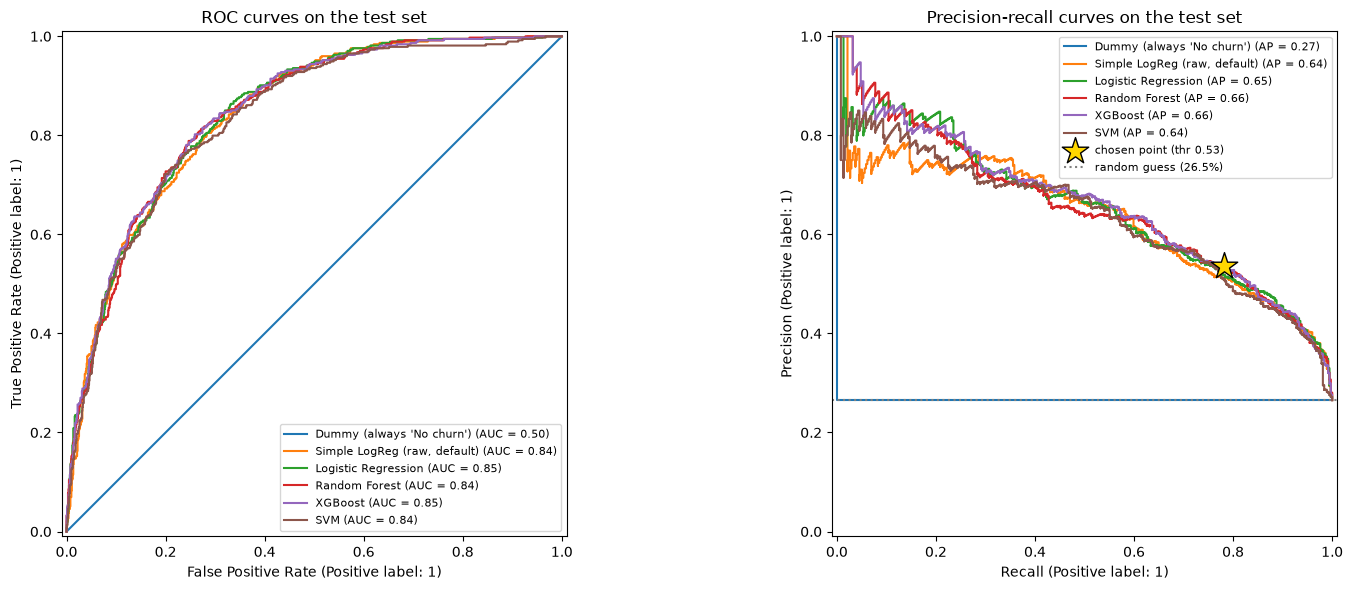

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))                           # ROC left, precision-recall right
for name, pipe in {**baselines, **tuned}.items():                         # every model, including the dummy
    scores = churn_scores(pipe, X_test)                                   # probability (or SVM decision value)
    RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=axes[0])   # one ROC curve per model
    PrecisionRecallDisplay.from_predictions(y_test, scores, name=name, ax=axes[1])  # one PR curve per model
final_row = test_results.iloc[-1]                                         # the final model at its tuned threshold
axes[1].scatter(final_row["recall"], final_row["precision"], marker="*", s=400, c="gold",  # its operating point
                edgecolors="black", zorder=5, label=f"chosen point (thr {best_threshold:.2f})")
axes[0].set_title("ROC curves on the test set")                           # chart title
axes[1].set_title("Precision-recall curves on the test set")              # chart title
axes[1].axhline(y_test.mean(), color="gray", linestyle=":", label="random guess (26.5%)")  # PR baseline
axes[1].legend(fontsize=8, loc="upper right")                             # legend
axes[0].legend(fontsize=8, loc="lower right")                             # legend
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

**What this cell does:** `RocCurveDisplay.from_predictions` and `PrecisionRecallDisplay.from_predictions` take the true labels and the churn scores and draw the curve, with the area under it (AUC / AP) in the legend. The dummy is the diagonal on the ROC plot (AUC 0.5) and the flat line at 26.5% on the PR plot. The four tuned models and the simple logistic regression lie almost **on top of each other** — they rank customers almost equally well; what differs between them is mostly **where** on the curve they operate (the threshold), not the curve itself. The gold star shows our chosen trade-off: about 78% recall at about 54% precision.

### 5.3 Classification report of the final model

**What I do and why:** I print the per-class report of my final model.

In [51]:
final_pred = (final_model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)  # final labels on the test set
print(f"{final_name}, threshold {best_threshold:.2f}\n")                 # header
print(classification_report(y_test, final_pred, target_names=["Stayed", "Churned"], digits=3))  # per-class metrics

Random Forest, threshold 0.53

              precision    recall  f1-score   support

      Stayed      0.905     0.756     0.824      1035
     Churned      0.536     0.781     0.635       374

    accuracy                          0.762      1409
   macro avg      0.720     0.768     0.730      1409
weighted avg      0.807     0.762     0.774      1409



**What this cell does:** `classification_report` prints precision, recall and F1 **for each class** plus the averages. The row that matters for the business is **Churned**: its recall is the share of leaving customers the model warns about, and its precision is the share of warnings that are real.

---
# Bonus — Feature importance and k-Means

### B1. Random Forest: which columns does it use? (impurity importance, engineered features)

**What I do and why:** I check which columns the Random Forest uses most, including my engineered features.

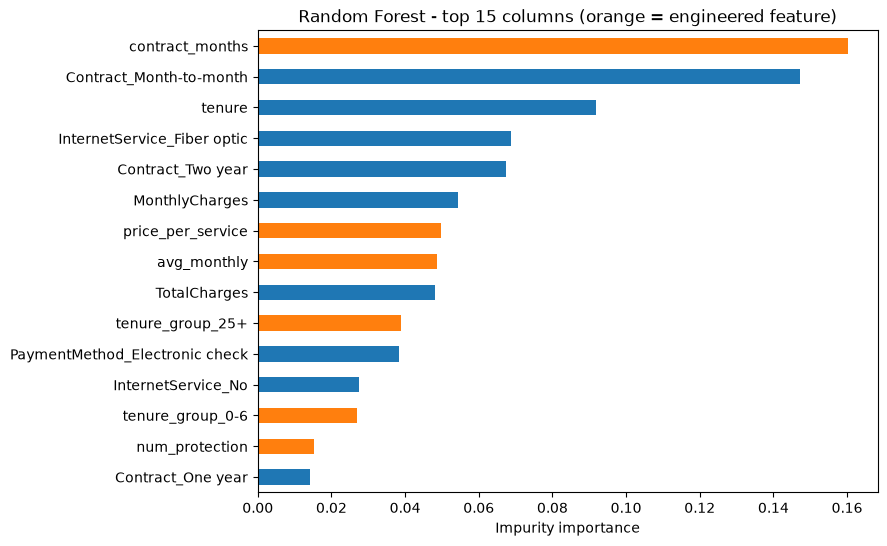

In [52]:
rf_pipe = tuned["Random Forest"]                                          # the tuned forest pipeline
names = rf_pipe.named_steps["prep"].get_feature_names_out()               # names of the 36 columns the model sees
names = [n.split("__", 1)[1] for n in names]                              # drop the 'num__' / 'cat__' prefixes
importances = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=names)  # one importance per column
top = importances.sort_values().tail(15)                                  # the 15 most important columns
colors = ["tab:orange" if any(n.startswith(f) for f in NEW_FEATURES) else "tab:blue" for n in top.index]  # orange = engineered
top.plot(kind="barh", color=colors, figsize=(8, 6))                       # horizontal bar chart
plt.title("Random Forest - top 15 columns (orange = engineered feature)")  # chart title
plt.xlabel("Impurity importance"); plt.show()                             # axis label + draw

**What this cell does:** `get_feature_names_out()` returns the names of the columns after preprocessing (e.g. `Contract_Two year`); `feature_importances_` measures how much each column reduced impurity (Gini) across all splits of all trees. Engineered features are coloured orange. The ordinal **`contract_months` is the single most important column**, ahead of the original `Contract` columns it was built from, and `price_per_service`, `avg_monthly`, both `tenure_group` bins and `num_protection` are also in the top 15. Together with section 4.3 this reproduces the Session 13 slide's twist: **the new features rise high in the importance ranking, yet the score barely changes**, because the importance simply moved from the original columns they were built from. No single column dominates the ranking (no "too good", leaking feature).

### B2. Permutation importance of the final model (test set, original columns)

Permutation importance shuffles **one original column** at a time and measures how much the test F1 drops. It works for any model and is measured on data the model never saw.

**What I do and why:** I measure, on the test set, how much each original column matters to my final model.

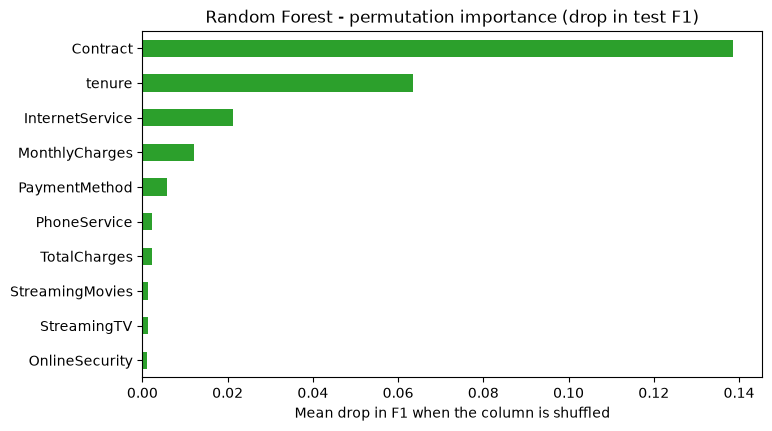

In [53]:
perm = permutation_importance(final_model, X_test, y_test, scoring="f1",  # shuffle each column, re-score F1
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)  # 10 shuffles per column
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()  # mean F1 drop per original column
perm_imp.tail(10).plot(kind="barh", color="tab:green")                    # the 10 most important columns
plt.title(f"{final_name} - permutation importance (drop in test F1)")     # chart title
plt.xlabel("Mean drop in F1 when the column is shuffled"); plt.show()     # axis label + draw

**What this cell does:** `permutation_importance` takes the fitted final pipeline, shuffles one of the **19 original columns** of `X_test` (breaking its link with the target), re-computes F1, and repeats 10 times; `importances_mean` is the average drop. Because the shuffled column flows through `add_features`, the importance of e.g. `tenure` also includes the features built from it (`tenure_group`, `avg_monthly`). The ranking confirms the EDA: **`Contract` is by far the most important column** (shuffling it costs ~0.14 F1), followed by **`tenure`**, then `InternetService`, `MonthlyCharges` and `PaymentMethod`; most other columns barely matter.

### B3. Logistic regression: direction of each effect (scaled coefficients)

Because the numeric columns were scaled (Step 2c), the coefficients are comparable: a positive coefficient pushes towards churn, a negative one away from it.

**What I do and why:** I read the logistic regression coefficients to see which features push churn up or down.

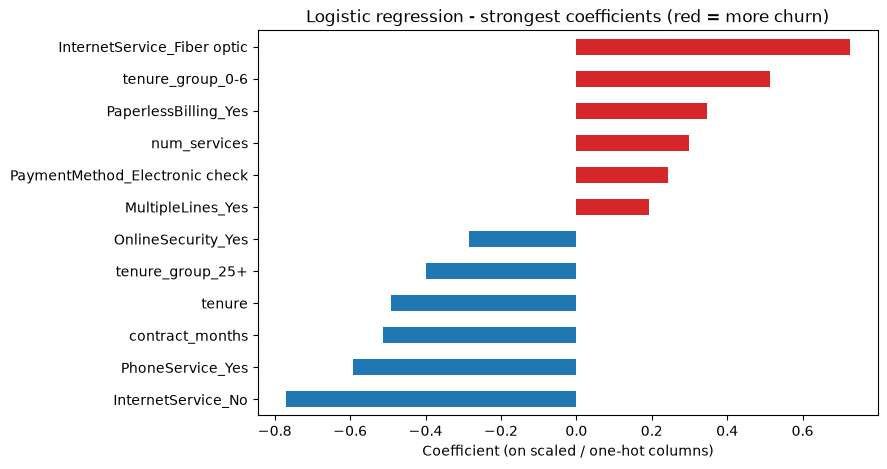

In [54]:
lr_pipe = tuned["Logistic Regression"]                                    # the tuned logistic regression pipeline
lr_names = [n.split("__", 1)[1] for n in lr_pipe.named_steps["prep"].get_feature_names_out()]  # readable column names
coefs = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=lr_names).sort_values()  # one coefficient per column
pd.concat([coefs.head(6), coefs.tail(6)]).plot(kind="barh",              # the 6 most negative and 6 most positive
    color=["tab:blue"] * 6 + ["tab:red"] * 6, figsize=(8, 5))            # blue = keeps customers, red = pushes to churn
plt.title("Logistic regression - strongest coefficients (red = more churn)")  # chart title
plt.xlabel("Coefficient (on scaled / one-hot columns)"); plt.show()       # axis label + draw

**What this cell does:** `coef_[0]` holds one weight per column in the log-odds of churn; sorting and keeping both ends shows the 6 strongest effects in each direction. Red bars **raise** the probability of churn — **fiber-optic internet**, being in the **first 6 months**, paperless billing, electronic-check payment — and blue bars **lower** it — **no internet service**, long tenure and longer contracts (`contract_months`), online security. These are associations inside the model, not proven causes, and correlated columns (e.g. `tenure`, `TotalCharges`, `tenure_group`) share the effect between them, so individual sizes should be read with care.

### B4. k-Means: customer segments (Session 10 recipe)

Unsupervised: k-Means does **not** see `Churn`. We cluster training customers on three scaled columns — `tenure`, `MonthlyCharges`, `num_services` — and only afterwards look at the churn rate of each segment. Scaling is mandatory here: k-Means uses distances (Session 10, exercise 5).

**What I do and why:** Bonus: I use k-Means to find customer segments without using the churn column, and choose k with the elbow method.

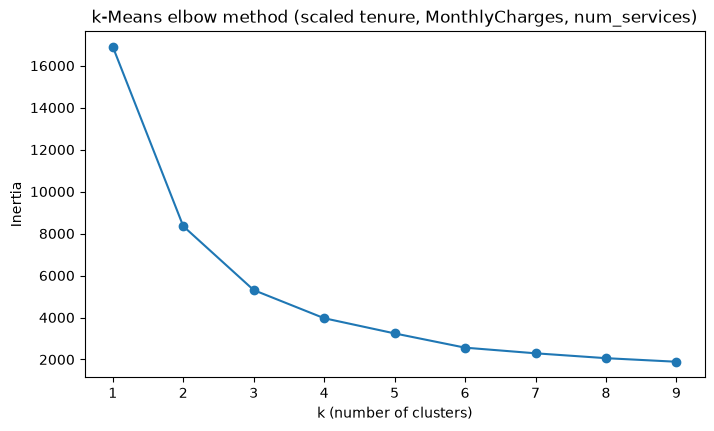

In [55]:
seg_cols = ["tenure", "MonthlyCharges", "num_services"]                   # the three columns used for segmentation
seg_X = StandardScaler().fit_transform(train_fe[seg_cols])                # scale them (training customers only)

inertias = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(seg_X).inertia_  # inertia for k = 1..9
            for k in range(1, 10)]
plt.plot(range(1, 10), inertias, "o-")                                    # the elbow curve
plt.title("k-Means elbow method (scaled tenure, MonthlyCharges, num_services)")  # chart title
plt.xlabel("k (number of clusters)"); plt.ylabel("Inertia"); plt.show()  # axis labels + draw

**What this cell does:** scales the three columns with `StandardScaler`, fits k-Means for k = 1…9 and plots the **inertia** (sum of squared distances from each customer to its cluster centre). Inertia always decreases as k grows; we look for the **elbow** where adding a cluster stops paying off. The big drops are from k = 1 to 3; the curve flattens after **k = 3–4**. We take **k = 4**: the 4th cluster still removes about a quarter of the remaining inertia, and four segments are still easy to describe.

**What I do and why:** I describe each segment and only then look at its churn rate.

In [56]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(seg_X)  # final segmentation with k = 4
train_fe["segment"] = kmeans.labels_                                      # the cluster id of every training customer
profile = train_fe.groupby("segment").agg(                                # describe each segment
    customers=("Churn", "size"),                                          # how many customers
    tenure=("tenure", "mean"),                                            # average months with the company
    monthly_charges=("MonthlyCharges", "mean"),                           # average monthly bill
    num_services=("num_services", "mean"),                                # average number of services
    churn_rate=("Churn", "mean"),                                         # share who churned (NOT used by k-Means)
).round(2).sort_values("churn_rate", ascending=False)                     # riskiest segment first
profile                                                                   # show the table

,customers,tenure,monthly_charges,num_services,churn_rate
segment,,,,,
1,1904,14.81,77.40,4.26,0.47
2,1212,10.43,29.16,1.65,0.23
3,1752,57.41,91.33,6.72,0.16
0,766,54.32,30.17,2.08,0.05


**What this cell does:** fits k-Means with k = 4, stores each customer's cluster in `segment`, and `groupby("segment").agg(...)` describes each cluster with its size, average tenure, bill and number of services, and — only now — its **churn rate**. Even though k-Means never saw the target, the segments have very different churn rates: the **newer, high-paying customers with several services** (about 15 months, ~$77/month) are by far the riskiest at **47%**, while **long-tenure customers with a low bill and few services** almost never leave (**5%**). This is a business-friendly summary of the same pattern the models learned: *the first months and a high bill are the danger zone.*

**What I do and why:** I plot the segments and their churn rates.

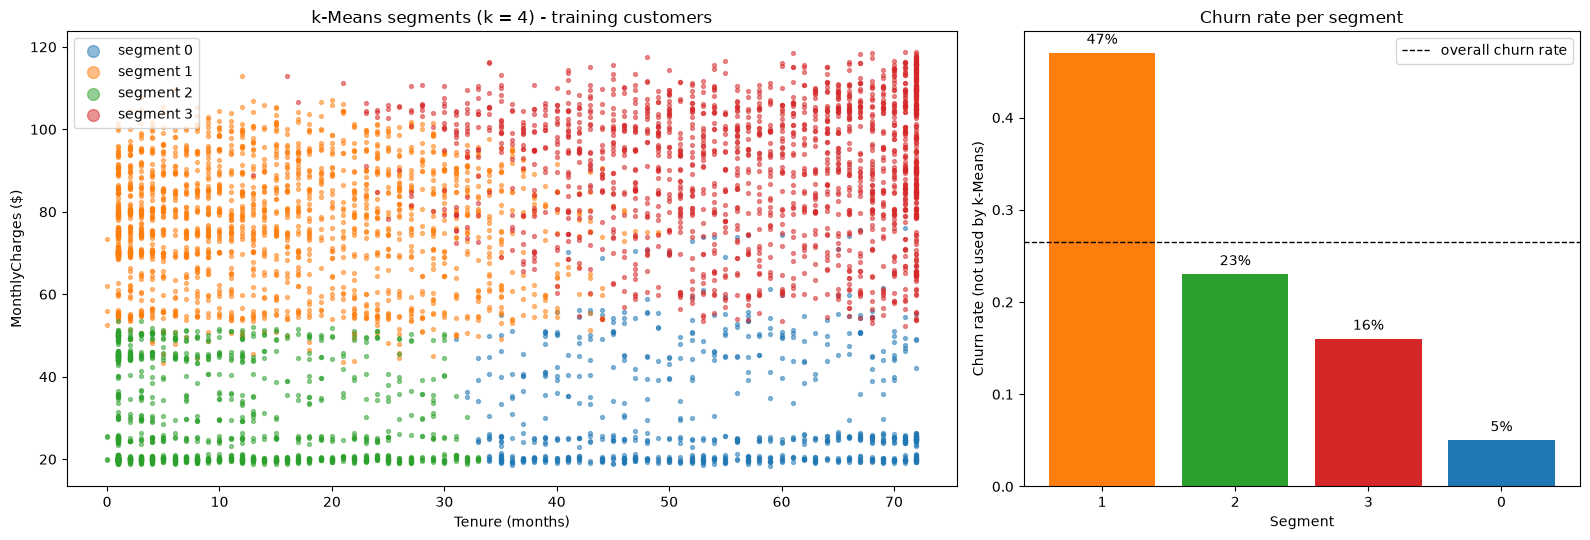

In [57]:
seg_colors = plt.cm.tab10.colors                                          # one fixed colour per segment id
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.6, 1]})  # scatter + bars
for seg in sorted(train_fe["segment"].unique()):                          # draw each segment in its own colour
    sub = train_fe[train_fe["segment"] == seg]                            # customers of this segment
    axes[0].scatter(sub["tenure"], sub["MonthlyCharges"], s=8, alpha=0.5,  # tenure vs bill
                    color=seg_colors[seg], label=f"segment {seg}")
axes[0].set_xlabel("Tenure (months)")                                     # x-axis label
axes[0].set_ylabel("MonthlyCharges ($)")                                  # y-axis label
axes[0].set_title("k-Means segments (k = 4) - training customers")        # chart title
axes[0].legend(markerscale=3)                                             # bigger legend dots
axes[1].bar(profile.index.astype(str), profile["churn_rate"],             # churn rate of each segment
            color=[seg_colors[s] for s in profile.index])                 # same colours as the scatter
for i, v in enumerate(profile["churn_rate"]):                             # write the rates
    axes[1].text(i, v + 0.01, f"{v:.0%}", ha="center")
axes[1].axhline(y_train.mean(), color="black", linestyle="--", lw=1, label="overall churn rate")  # reference line
axes[1].set_xlabel("Segment")                                             # x-axis label
axes[1].set_ylabel("Churn rate (not used by k-Means)")                    # y-axis label
axes[1].set_title("Churn rate per segment")                               # chart title
axes[1].legend()                                                          # legend
plt.tight_layout()                                                        # avoid overlaps
plt.show()                                                                # draw it

**What this cell does:** left: every training customer at (tenure, monthly bill), coloured by its k-Means segment (the third clustering column, `num_services`, is not on the axes, which is why some colours overlap). Right: the churn rate of each segment in the same colours. The k-Means segments cut the customer base into "new vs long-standing" and "cheap vs expensive" groups, and the **new + expensive** segment stands out as the riskiest, without k-Means ever having seen the `Churn` column.

---
# Step 6 — Conclusion

### Recommended model

**Random Forest** (tuned: 559 trees, `max_depth = 10`, `min_samples_leaf = 33`, `max_features = "sqrt"`, `class_weight = "balanced"`), on the engineered features, with a decision threshold of **0.53**.

On the **test set** (1,409 customers, used once):

| | Dummy | Simple LogReg | **Final Random Forest** |
|---|---|---|---|
| Churners caught (of 374) | 0 | 208 | **292** |
| Recall | 0.000 | 0.556 | **0.781** |
| Precision | 0.000 | 0.654 | 0.536 |
| **F1 (main metric)** | 0.000 | 0.601 | **0.635** |
| Accuracy | 0.735 | 0.804 | 0.762 |
| ROC-AUC | 0.500 | 0.842 | 0.845 |

### How much it beats the baseline

* Against the **dummy**: F1 goes from **0 to 0.635** and the model catches **292 of the 374** churners the dummy misses entirely — while accuracy rises by only 2.7 points (0.735 → 0.762), which shows once more why accuracy was the wrong scoreboard.
* Against the **simple logistic regression**: **+0.034 F1** and **+0.225 recall**: **84 more churners caught**, at the cost of 143 more false alarms.
* The test F1 (0.635) is the same as the cross-validated F1 (0.635 ± 0.012), so the CV estimate was **honest** — no sign of overfitting to the training data or to the tuning.

### What made the difference (in order of impact)

1. **Class weighting** (`class_weight="balanced"` / `scale_pos_weight`): recall from ~0.54 to ~0.80 — by far the biggest gain.
2. **Tuning**: +0.00 to +0.02 F1 depending on the model (the forest gained most, by being made shallower and smoother).
3. **Feature engineering**: ±0.003 F1 — within the noise, although the new features top the importance ranking (the Session 13 lesson).
4. **Threshold tuning**: +0.002 F1 — the class weighting had already moved the decision boundary.

Logistic Regression, Random Forest and XGBoost are **statistically tied** (CV F1 0.632–0.635, differences smaller than the fold spread). We follow our pre-declared rule and recommend the best CV score, the Random Forest; if interpretability mattered more than the last thousandth of F1, the **logistic regression** (test F1 0.622, readable coefficients) would be an equally defensible choice.

### Limitations

* **One snapshot, no history.** The data is a single picture of each customer: no monthly usage, no support calls, no price changes over time. That kind of *new* information is what feature engineering cannot invent from the existing columns, and it is the most likely way to really improve the score.
* **The threshold maximises F1, not money.** We do not know the real cost of a retention offer or the value of a lost customer; with those numbers, the threshold should be chosen to minimise the business cost and would probably be lower (more recall, less precision).
* **Precision is ~0.54**: almost half of the customers we flag would have stayed anyway, so the retention action must be cheap enough to be worth it.
* **One company, one dataset** (an IBM sample dataset of a single telecom operator): the model would need to be re-validated before being used anywhere else.

### Visual summary

**What I do and why:** I summarise what each step added to the score and how many churners my model catches.

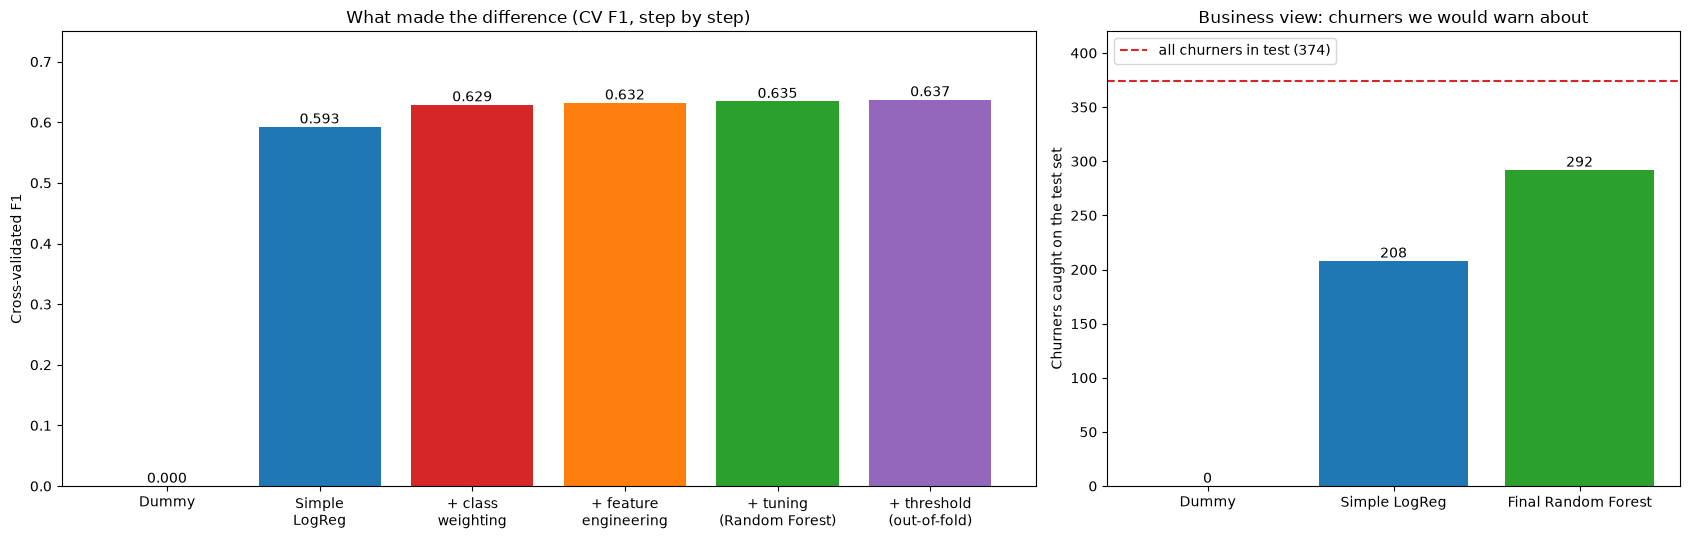

In [58]:
journey = pd.Series({                                                      # cross-validated F1 (training set), step by step
    "Dummy": baseline_results.loc["Dummy (always 'No churn')", "f1"],
    "Simple\nLogReg": baseline_results.loc["Simple LogReg (raw, default)", "f1"],
    "+ class\nweighting": model_results.loc[("Logistic Regression", "raw"), "f1"],
    "+ feature\nengineering": model_results.loc[("Logistic Regression", "engineered"), "f1"],
    f"+ tuning\n({final_name})": tuned_results.loc[final_name, "f1"],
    "+ threshold\n(out-of-fold)": max(f1s),
})
caught = pd.Series({                                                       # test set: churners caught out of 374
    "Dummy": 0,
    "Simple LogReg": int(((baselines["Simple LogReg (raw, default)"].predict(X_test) == 1) & (y_test == 1)).sum()),
    f"Final {final_name}": int(((final_pred == 1) & (y_test == 1)).sum()),
})

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1.7, 1]})  # two charts
bars = axes[0].bar(journey.index, journey.values,                          # one bar per improvement step
                   color=["lightgray", "tab:blue", "tab:red", "tab:orange", "tab:green", "tab:purple"])
axes[0].bar_label(bars, fmt="%.3f")                                        # value on top of every bar
axes[0].set_ylim(0, 0.75)                                                  # room for the labels
axes[0].set_ylabel("Cross-validated F1")                                   # y-axis label
axes[0].set_title("What made the difference (CV F1, step by step)")        # chart title
bars = axes[1].bar(caught.index, caught.values, color=["lightgray", "tab:blue", "tab:green"])  # churners caught
axes[1].bar_label(bars)                                                    # the counts
axes[1].axhline(int(y_test.sum()), color="tab:red", linestyle="--", label=f"all churners in test ({int(y_test.sum())})")
axes[1].set_ylim(0, 420)                                                   # room for the labels
axes[1].set_ylabel("Churners caught on the test set")                      # y-axis label
axes[1].set_title("Business view: churners we would warn about")           # chart title
axes[1].legend(loc="upper left")                                           # legend
plt.tight_layout()                                                         # avoid overlaps
plt.show()                                                                 # draw it

**What this cell does:** left: the cross-validated F1 after each ingredient, in the order we added them — from 0 (dummy) to the simple logistic regression, then class weighting (**the big jump**), feature engineering (flat), tuning (small) and the threshold (tiny). Right: the business view on the test set — how many of the 374 real churners each model would have warned us about.